In [1]:
import pandas as pd

orders = pd.read_csv(
    '/content/olist_orders_dataset2(Cleaned data).csv',
    encoding='latin1'
)

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,Approval_Delay_Hours,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,Delivery_Delay_Days,Delivery_Status,Delivery_Delay_Category,Carrier_Handover_Days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/17 10:56 AM,10/2/17 11:07 AM,0.18,10/4/17 7:55 PM,10/10/17 9:25 PM,10/18/17 12:00 AM,8.44,-7.11,Early,On Time / Early,2.37
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/18 8:41 PM,7/26/18 3:24 AM,30.71,7/26/18 2:31 PM,8/7/18 3:27 PM,8/13/18 12:00 AM,13.78,-5.36,Early,On Time / Early,1.74
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/18 8:38 AM,8/8/18 8:55 AM,0.28,8/8/18 1:50 PM,8/17/18 6:06 PM,9/4/18 12:00 AM,9.39,-17.25,Early,On Time / Early,0.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,11/18/17 7:28 PM,11/18/17 7:45 PM,0.30,11/22/17 1:39 PM,12/2/17 12:28 AM,12/15/17 12:00 AM,13.21,-12.98,Early,On Time / Early,3.76
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2/13/18 9:18 PM,2/13/18 10:20 PM,1.03,2/14/18 7:46 PM,2/16/18 6:17 PM,2/26/18 12:00 AM,2.87,-9.24,Early,On Time / Early,0.94


In [2]:
orders.shape

(99441, 14)

In [3]:
orders.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'Approval_Delay_Hours',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_days',
 'Delivery_Delay_Days',
 'Delivery_Status',
 'Delivery_Delay_Category',
 'Carrier_Handover_Days']

In [4]:
orders.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
Approval_Delay_Hours,float64
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object
delivery_days,float64


In [5]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

orders[date_columns].dtypes

/tmp/ipykernel_1062/3320242223.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders[col] = pd.to_datetime(orders[col], errors='coerce')
/tmp/ipykernel_1062/3320242223.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders[col] = pd.to_datetime(orders[col], errors='coerce')
/tmp/ipykernel_1062/3320242223.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders[col] = pd.to_datetime(orders[col], errors='coerce')
/tmp/ipykernel_1062/3320242223.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To 

,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [6]:
orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
Approval_Delay_Hours,0
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0
delivery_days,2965


In [7]:
orders.groupby('order_status').agg(
    Orders=('order_id', 'count'),
    Missing_Delivery_Date=('order_delivered_customer_date', lambda x: x.isna().sum()),
    Missing_Carrier_Date=('order_delivered_carrier_date', lambda x: x.isna().sum())
)

,Orders,Missing_Delivery_Date,Missing_Carrier_Date
order_status,,,
approved,2,2,2
canceled,625,619,550
created,5,5,5
delivered,96478,8,2
invoiced,314,314,314
processing,301,301,301
shipped,1107,1107,0
unavailable,609,609,609


In [8]:
orders.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,99441,99441,66dea50a8b16d9b4dee7af250b4be1a5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,99441,99441,edb027a75a1449115f6b43211ae02a24,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,99441,8,delivered,96478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,99441,NaN,NaN,NaN,2017-12-31 08:42:43.256403200,2016-09-04 21:15:00,2017-09-12 14:46:00,2018-01-18 23:04:00,2018-05-04 15:42:00,2018-10-17 17:30:00,NaN
order_approved_at,99281,NaN,NaN,NaN,2017-12-31 18:34:57.504054016,2016-09-15 12:16:00,2017-09-12 23:24:00,2018-01-19 11:36:00,2018-05-04 20:35:00,2018-09-03 17:40:00,NaN
Approval_Delay_Hours,99441.0,NaN,NaN,NaN,-1654.503799,-1041377.51,0.21,0.34,14.54,4509.18,41473.981989
order_delivered_carrier_date,97658,NaN,NaN,NaN,2018-01-04 21:49:25.250773248,2016-10-08 10:34:00,2017-09-15 22:28:00,2018-01-24 16:10:30,2018-05-08 13:37:45,2018-09-11 19:48:00,NaN
order_delivered_customer_date,96476,NaN,NaN,NaN,2018-01-14 12:08:45.733239552,2016-10-11 13:46:00,2017-09-25 22:06:45,2018-02-02 19:27:30,2018-05-15 22:48:00,2018-10-17 13:22:00,NaN
order_estimated_delivery_date,99441,NaN,NaN,NaN,2018-01-24 03:08:37.730111232,2016-09-30 00:00:00,2017-10-03 00:00:00,2018-02-15 00:00:00,2018-05-25 00:00:00,2018-11-12 00:00:00,NaN
delivery_days,96476.0,NaN,NaN,NaN,12.558688,0.53,6.77,10.22,15.72,209.63,9.546529


In [9]:
orders['Delivery_Status'].value_counts(dropna=False)

,count
Delivery_Status,
Early,88649
Late,7827
Not Delivered,2965


In [10]:
orders['Delivery_Status'].value_counts(normalize=True).mul(100).round(2)

,proportion
Delivery_Status,
Early,89.15
Late,7.87
Not Delivered,2.98


In [11]:
delivered_orders = orders[
    orders['Delivery_Status'].isin(['Early', 'Late'])
]

on_time_delivery_pct = (
    (delivered_orders['Delivery_Status'] == 'Early').mean() * 100
)

round(on_time_delivery_pct, 2)

np.float64(91.89)

In [12]:
orders.loc[
    orders['Delivery_Status'] == 'Late',
    'Delivery_Delay_Days'
].describe()

,Delivery_Delay_Days
count,7827.000000
mean,9.552183
std,13.951740
min,0.000000
25%,1.870000
50%,5.810000
75%,11.820000
max,188.980000


In [13]:
orders.loc[
    orders['Delivery_Status'] == 'Late',
    'Delivery_Delay_Days'
].value_counts().sort_index().head(20)

,count
Delivery_Delay_Days,
0.00,6
0.01,11
0.02,15
0.03,16
0.04,11
0.05,5
0.06,6
0.07,4
0.08,4


In [14]:
orders.loc[
    (orders['Delivery_Status'] == 'Late') &
    (orders['Delivery_Delay_Days'] <= 0.01),
    [
        'order_id',
        'order_purchase_timestamp',
        'order_estimated_delivery_date',
        'order_delivered_customer_date',
        'Delivery_Delay_Days',
        'Delivery_Status'
    ]
]

,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,Delivery_Delay_Days,Delivery_Status
16132,99aa87bbe1515eb7af7c662a11e95436,2017-11-13 14:58:00,2017-12-12,2017-12-12 00:08:00,0.01,Late
26369,23c95653bc574efa346f4eee3b29e882,2017-11-20 12:47:00,2017-12-08,2017-12-08 00:21:00,0.01,Late
28349,d736ac2dcec087fda2b4ed1eb5a5032b,2018-02-28 11:31:00,2018-03-28,2018-03-28 00:08:00,0.01,Late
33481,395363317a9cc3945212a000edf960d3,2018-02-21 20:49:00,2018-03-21,2018-03-21 00:17:00,0.01,Late
34736,308163f9666c3f335e92b0f0f61554ed,2018-07-12 11:24:00,2018-08-01,2018-08-01 00:05:00,0.00,Late
47556,5989369fa081195d8762312fad7d588d,2018-05-14 16:31:00,2018-06-05,2018-06-05 00:05:00,0.00,Late
49056,fa6d52aa0f15a0a03c1f945a1d0f996f,2018-08-09 14:05:00,2018-08-21,2018-08-21 00:15:00,0.01,Late
57100,c1ecc15bc30548ecad160437f07df801,2018-04-25 17:38:00,2018-05-22,2018-05-22 00:04:00,0.00,Late
57212,0eae0847dbceff8611d706710c724ee2,2017-11-16 12:29:00,2017-12-12,2017-12-12 00:04:00,0.00,Late
60062,0a06917fb1c4d93dddc71d9ca7dd8790,2018-08-08 21:30:00,2018-08-30,2018-08-30 00:16:00,0.01,Late


In [15]:
orders['Estimated_Date'] = orders['order_estimated_delivery_date'].dt.date
orders['Delivered_Date'] = orders['order_delivered_customer_date'].dt.date

orders.loc[
    orders['Delivery_Status'] == 'Late',
    ['Estimated_Date', 'Delivered_Date', 'Delivery_Delay_Days']
].head(20)

,Estimated_Date,Delivered_Date,Delivery_Delay_Days
20,2017-09-28,2017-10-09,11.93
25,2018-03-12,2018-03-21,9.92
35,2018-03-20,2018-03-20,0.04
41,2017-12-21,2017-12-28,7.79
57,2018-04-02,2018-04-03,1.56
58,2017-03-30,2017-04-06,7.57
97,2017-12-11,2017-12-28,17.82
102,2018-08-02,2018-08-03,1.81
110,2017-12-22,2018-01-23,32.90
115,2017-12-19,2018-01-20,32.57


In [16]:
same_day_late = orders[
    (orders['Delivery_Status'] == 'Late') &
    (orders['Estimated_Date'] == orders['Delivered_Date'])
]

print("Same-day deliveries classified as Late:", len(same_day_late))
print("Percentage of Late orders:",
      round(len(same_day_late) / (orders['Delivery_Status'] == 'Late').sum() * 100, 2))

Same-day deliveries classified as Late: 1292
Percentage of Late orders: 16.51


In [17]:
same_day_late['Delivery_Delay_Days'].describe()

,Delivery_Delay_Days
count,1292.000000
mean,0.698986
std,0.235888
min,0.000000
25%,0.620000
50%,0.750000
75%,0.860000
max,1.000000


In [18]:
orders['Delivery_Status_Date'] = orders.apply(
    lambda row:
        'Not Delivered' if pd.isna(row['Delivered_Date'])
        else 'Early' if row['Delivered_Date'] < row['Estimated_Date']
        else 'On Time' if row['Delivered_Date'] == row['Estimated_Date']
        else 'Late',
    axis=1
)

orders['Delivery_Status_Date'].value_counts()

,count
Delivery_Status_Date,
Early,88649
Late,6535
Not Delivered,2965
On Time,1292


In [19]:
# Check overall delivery delay distribution
orders['Delivery_Delay_Days'].describe()

,Delivery_Delay_Days
count,96476.000000
mean,-11.179117
std,10.186117
min,-146.020000
25%,-16.240000
50%,-11.950000
75%,-6.390000
max,188.980000


In [20]:
# Check how many orders were delivered before the estimated date
negative_delays = orders[
    orders['Delivery_Delay_Days'] < 0
]

print("Orders delivered before estimated date:", len(negative_delays))
print(
    "Percentage:",
    round(len(negative_delays) / orders['Delivery_Delay_Days'].notna().sum() * 100, 2),
    "%"
)

Orders delivered before estimated date: 88639
Percentage: 91.88 %


In [21]:
# Inspect orders with unusually early delivery
orders.loc[
    orders['Delivery_Delay_Days'] < -30,
    [
        'order_id',
        'order_purchase_timestamp',
        'Estimated_Date',
        'Delivered_Date',
        'Delivery_Delay_Days',
        'Delivery_Status_Date'
    ]
].sort_values('Delivery_Delay_Days').head(20)

,order_id,order_purchase_timestamp,Estimated_Date,Delivered_Date,Delivery_Delay_Days,Delivery_Status_Date
40094,0607f0efea4b566f1eb8f7d3c2397320,2018-03-06 09:47:00,2018-08-03,2018-03-09,-146.02,Early
15791,c72727d29cde4cf870d569bf65edabfd,2017-02-07 18:01:00,2017-07-04,2017-02-14,-139.40,Early
57160,eec7f369423b033e549c02f3c5381205,2018-02-06 20:44:00,2018-07-12,2018-02-27,-134.31,Early
86444,c2bb89b5c1dd978d507284be78a04cb2,2017-05-23 22:28:00,2017-10-11,2017-06-09,-123.43,Early
67488,40dc2ba6f322a17626aac6244332828c,2017-10-05 21:39:00,2018-01-30,2017-10-13,-108.42,Early
79449,1a695d543b7302aa9446c8d5fbd632bf,2017-12-16 10:32:00,2018-03-22,2017-12-28,-83.07,Early
62706,39e0115911bf404857e14baa7f097feb,2018-01-20 07:48:00,2018-04-25,2018-02-01,-82.92,Early
95849,559eea5a72341a4c82dbce9884277cb7,2017-11-17 10:24:00,2018-02-16,2017-11-30,-77.32,Early
63537,38930f76efb00b138f4d632e4d557341,2018-01-28 13:47:00,2018-04-27,2018-02-08,-77.19,Early
37491,c5132855100a12d63ed4e8ae05f9594d,2017-10-13 14:45:00,2018-01-11,2017-10-25,-77.15,Early


In [22]:
# Count extremely early deliveries
extreme_early = orders[
    orders['Delivery_Delay_Days'] < -30
]

print("Orders delivered more than 30 days early:", len(extreme_early))

print(
    "Percentage:",
    round(
        len(extreme_early) /
        orders['Delivery_Delay_Days'].notna().sum() * 100,
        2
    ),
    "%"
)

Orders delivered more than 30 days early: 2354
Percentage: 2.44 %


In [23]:
# Analyse late delivery delays
late_delays = orders[
    orders['Delivery_Delay_Days'] > 0
]['Delivery_Delay_Days']

late_delays.describe()

,Delivery_Delay_Days
count,7821.000000
mean,9.559512
std,13.954581
min,0.010000
25%,1.870000
50%,5.810000
75%,11.840000
max,188.980000


In [24]:
# Check the distribution of late-delivery delays

delay_bins = [0, 3, 7, 14, 30, 60, 90, float('inf')]
delay_labels = [
    '0–3 days',
    '3–7 days',
    '7–14 days',
    '14–30 days',
    '30–60 days',
    '60–90 days',
    '90+ days'
]

late_delay_buckets = pd.cut(
    late_delays,
    bins=delay_bins,
    labels=delay_labels,
    right=True,
    include_lowest=True
)

late_delay_buckets.value_counts().sort_index()

,count
Delivery_Delay_Days,
0–3 days,2660
3–7 days,1819
7–14 days,1787
14–30 days,1195
30–60 days,276
60–90 days,37
90+ days,47


In [25]:
# Investigate orders delayed by more than 90 days

extreme_late = orders[
    orders['Delivery_Delay_Days'] > 90
]

extreme_late[
    [
        'order_id',
        'order_purchase_timestamp',
        'Estimated_Date',
        'Delivered_Date',
        'Delivery_Delay_Days',
        'Delivery_Status_Date'
    ]
].sort_values(
    'Delivery_Delay_Days',
    ascending=False
)

,order_id,order_purchase_timestamp,Estimated_Date,Delivered_Date,Delivery_Delay_Days,Delivery_Status_Date
55619,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-23 14:57:00,2018-03-15,2018-09-19,188.98,Late
19590,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:00,2017-03-22,2017-09-19,181.61,Late
11399,47b40429ed8cce3aee9199792275433f,2018-01-03 09:44:00,2018-01-19,2018-07-13,175.87,Late
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:00,2017-04-05,2017-09-19,167.71,Late
89130,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:00,2017-04-06,2017-09-19,166.58,Late
61610,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:00,2017-04-07,2017-09-19,165.63,Late
68769,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:00,2017-04-10,2017-09-19,162.72,Late
40847,d24e8541128cea179a11a65176e0a96f,2017-06-12 13:14:00,2017-06-26,2017-12-04,161.78,Late
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:00,2017-04-11,2017-09-19,161.61,Late
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:00,2017-04-13,2017-09-19,159.61,Late


In [26]:
# Check how many late orders were delivered on 2017-09-19

orders[
    (orders['Delivery_Delay_Days'] > 90) &
    (orders['Delivered_Date'] == '2017-09-19')
].shape[0]

0

In [27]:
# Percentage of 90+ day late orders delivered on 2017-09-19

round(
    (
        (
            (orders['Delivery_Delay_Days'] > 90) &
            (orders['Delivered_Date'] == '2017-09-19')
        ).sum()
        /
        (orders['Delivery_Delay_Days'] > 90).sum()
    ) * 100,
    2
)

np.float64(0.0)

In [28]:
# Check the delivery dates of extremely late orders

extreme_late['Delivered_Date'].value_counts().head(15)

,count
Delivered_Date,
2017-09-19,21
2018-02-27,1
2018-02-05,1
2018-07-13,1
2018-05-23,1
2018-08-20,1
2018-07-26,1
2018-10-17,1
2017-06-14,1


In [29]:
# Inspect the 90+ day late orders delivered on 2017-09-19

extreme_late_0919 = extreme_late[
    extreme_late['Delivered_Date'] == pd.to_datetime('2017-09-19').date()
]

extreme_late_0919[
    [
        'order_id',
        'order_purchase_timestamp',
        'Estimated_Date',
        'Delivered_Date',
        'Delivery_Delay_Days',
        'Delivery_Status_Date'
    ]
].sort_values('Delivery_Delay_Days', ascending=False)

,order_id,order_purchase_timestamp,Estimated_Date,Delivered_Date,Delivery_Delay_Days,Delivery_Status_Date
19590,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:00,2017-03-22,2017-09-19,181.61,Late
81401,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:00,2017-04-05,2017-09-19,167.71,Late
89130,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:00,2017-04-06,2017-09-19,166.58,Late
61610,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:00,2017-04-07,2017-09-19,165.63,Late
68769,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:00,2017-04-10,2017-09-19,162.72,Late
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:00,2017-04-11,2017-09-19,161.61,Late
54480,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:00,2017-04-13,2017-09-19,159.61,Late
70307,2fb597c2f772eca01b1f5c561bf6cc7b,2017-03-08 18:09:00,2017-04-17,2017-09-19,155.61,Late
31228,dfe5f68118c2576143240b8d78e5940a,2017-03-17 12:32:00,2017-04-19,2017-09-19,153.76,Late
62286,437222e3fd1b07396f1d9ba8c15fba59,2017-03-16 11:36:00,2017-04-28,2017-09-19,144.69,Late


In [30]:
# Investigate the 21 extremely late orders

extreme_late_0919[
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'Estimated_Date',
        'Delivered_Date',
        'Delivery_Delay_Days'
    ]
].sort_values('Delivery_Delay_Days', ascending=False)

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,Estimated_Date,Delivered_Date,Delivery_Delay_Days
19590,ca07593549f1816d26a572e06dc1eab6,delivered,2017-02-21 23:31:00,2017-02-23 02:35:00,2017-03-08 13:47:00,2017-03-22,2017-09-19,181.61
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,2017-03-13 20:17:00,2017-03-13 20:17:00,2017-03-17 07:23:00,2017-04-05,2017-09-19,167.71
89130,285ab9426d6982034523a855f55a885e,delivered,2017-03-08 22:47:00,2017-03-08 22:47:00,2017-03-09 08:53:00,2017-04-06,2017-09-19,166.58
61610,440d0d17af552815d15a9e41abe49359,delivered,2017-03-07 23:59:00,2017-03-09 01:11:00,2017-03-15 13:00:00,2017-04-07,2017-09-19,165.63
68769,c27815f7e3dd0b926b58552628481575,delivered,2017-03-15 23:23:00,2017-03-15 23:23:00,2017-03-21 14:50:00,2017-04-10,2017-09-19,162.72
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,2017-03-09 13:26:00,2017-03-09 13:26:00,2017-03-22 05:28:00,2017-04-11,2017-09-19,161.61
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,2017-03-15 11:24:00,2017-03-15 11:24:00,2017-03-16 09:29:00,2017-04-13,2017-09-19,159.61
70307,2fb597c2f772eca01b1f5c561bf6cc7b,delivered,2017-03-08 18:09:00,2017-03-08 18:09:00,2017-03-13 08:54:00,2017-04-17,2017-09-19,155.61
31228,dfe5f68118c2576143240b8d78e5940a,delivered,2017-03-17 12:32:00,2017-03-17 12:32:00,2017-03-21 18:28:00,2017-04-19,2017-09-19,153.76
62286,437222e3fd1b07396f1d9ba8c15fba59,delivered,2017-03-16 11:36:00,2017-03-16 11:36:00,2017-03-21 08:22:00,2017-04-28,2017-09-19,144.69


In [31]:
# Check how many orders were delivered on 2017-09-19
# and compare them with extremely late orders

orders[orders['Delivered_Date'] == '2017-09-19'][
    ['order_id', 'Estimated_Date', 'Delivered_Date', 'Delivery_Delay_Days']
].sort_values('Delivery_Delay_Days', ascending=False).head(30)

,order_id,Estimated_Date,Delivered_Date,Delivery_Delay_Days


In [32]:
orders['Delivered_Date'].dtype

dtype('O')

In [33]:
orders['Delivered_Date'].value_counts().head(20)

,count
Delivered_Date,
2018-08-27,446
2018-08-13,442
2018-05-14,434
2018-05-21,431
2018-05-18,425
2018-04-11,413
2017-12-11,412
2018-07-03,410
2018-05-03,409


In [34]:
# Check how many orders were delivered on 2017-09-19
orders[orders['Delivered_Date'] == '2017-09-19'].shape[0]

0

In [35]:
# Inspect the exact stored value
orders['Delivered_Date'].dropna().iloc[0], repr(orders['Delivered_Date'].dropna().iloc[0])

(datetime.date(2017, 10, 10), 'datetime.date(2017, 10, 10)')

In [36]:
# Find dates containing 2017-09-19
orders[
    orders['Delivered_Date'].astype(str).str.contains('2017-09-19', na=False)
]['Delivered_Date'].value_counts()

,count
Delivered_Date,
2017-09-19,282


In [37]:
# Percentage of 90+ day late orders delivered on 2017-09-19

late_orders_0919 = orders[
    (orders['Delivery_Delay_Days'] > 90) &
    (orders['Delivered_Date'] == pd.to_datetime('2017-09-19').date())
]

total_orders_0919 = orders[
    orders['Delivered_Date'] == pd.to_datetime('2017-09-19').date()
]

round(
    len(late_orders_0919) / len(total_orders_0919) * 100,
    2
)

7.45

In [38]:
import os

[x for x in os.listdir('/content') if 'customer' in x.lower()]

['olist_customers_dataset 3(Cleaned data) (1).csv']

In [39]:
import pandas as pd

customers = pd.read_csv(
    '/content/olist_customers_dataset 3(Cleaned data) (1).csv',
    encoding='latin1'
)

print("Customers loaded successfully!")
print("Shape:", customers.shape)

Customers loaded successfully!
Shape: (99441, 6)


In [40]:
# ==========================================
# CUSTOMER EDA — DATA QUALITY & STRUCTURE
# ==========================================

print("CUSTOMERS SHAPE:")
print(customers.shape)

print("\nCUSTOMER COLUMNS:")
print(customers.columns.tolist())

print("\nDATA TYPES:")
print(customers.dtypes)

print("\nMISSING VALUES:")
print(customers.isnull().sum())

print("\nDUPLICATE CUSTOMER_ID:")
print(customers['customer_id'].duplicated().sum())

print("\nUNIQUE CUSTOMER_ID:")
print(customers['customer_id'].nunique())

print("\nUNIQUE CUSTOMER_UNIQUE_ID:")
print(customers['customer_unique_id'].nunique())

print("\nCUSTOMER SEGMENTS:")
print(customers['Customer segment'].value_counts())

print("\nCUSTOMER STATES:")
print(customers['customer_state'].value_counts().head(15))

print("\nTOP CUSTOMER CITIES:")
print(customers['customer_city'].value_counts().head(15))

CUSTOMERS SHAPE:
(99441, 6)

CUSTOMER COLUMNS:
['customer_id', 'customer_unique_id', 'Customer segment', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

DATA TYPES:
customer_id                 object
customer_unique_id          object
Customer segment            object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

MISSING VALUES:
customer_id                 0
customer_unique_id          0
Customer segment            0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

DUPLICATE CUSTOMER_ID:
0

UNIQUE CUSTOMER_ID:
99441

UNIQUE CUSTOMER_UNIQUE_ID:
96096

CUSTOMER SEGMENTS:
Customer segment
New Customer       93099
Repeat Customer     6342
Name: count, dtype: int64

CUSTOMER STATES:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      

In [41]:
# ==========================================
# CUSTOMER SEGMENT VALIDATION
# ==========================================

customer_frequency = (
    customers.groupby('customer_unique_id')['customer_id']
    .count()
    .reset_index(name='customer_id_count')
)

customer_frequency['Calculated_Segment'] = customer_frequency['customer_id_count'].apply(
    lambda x: 'Repeat Customer' if x > 1 else 'New Customer'
)

print("CALCULATED CUSTOMER SEGMENT:")
print(customer_frequency['Calculated_Segment'].value_counts())

print("\nCUSTOMER RECORDS BY CUSTOMER UNIQUE ID:")
print(customer_frequency['customer_id_count'].value_counts().sort_index().head(15))

print("\nCUSTOMER UNIQUE IDs WITH MORE THAN ONE CUSTOMER_ID:")
print((customer_frequency['customer_id_count'] > 1).sum())

print("\nTOTAL CUSTOMER RECORDS BELONGING TO REPEAT CUSTOMERS:")
print(
    customer_frequency.loc[
        customer_frequency['customer_id_count'] > 1,
        'customer_id_count'
    ].sum()
)

CALCULATED CUSTOMER SEGMENT:
Calculated_Segment
New Customer       93099
Repeat Customer     2997
Name: count, dtype: int64

CUSTOMER RECORDS BY CUSTOMER UNIQUE ID:
customer_id_count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

CUSTOMER UNIQUE IDs WITH MORE THAN ONE CUSTOMER_ID:
2997

TOTAL CUSTOMER RECORDS BELONGING TO REPEAT CUSTOMERS:
6342


In [42]:
# ==========================================
# CUSTOMER SEGMENT CONSISTENCY CHECK
# ==========================================

customers_check = customers[['customer_unique_id', 'Customer segment']].copy()

customers_check = customers_check.merge(
    customer_frequency[['customer_unique_id', 'Calculated_Segment']],
    on='customer_unique_id',
    how='left'
)

print("SEGMENT COMPARISON:")
print(
    pd.crosstab(
        customers_check['Customer segment'],
        customers_check['Calculated_Segment']
    )
)

print("\nMISMATCHED RECORDS:")
mismatch_count = (
    customers_check['Customer segment']
    != customers_check['Calculated_Segment']
).sum()

print(mismatch_count)

print("\nSEGMENT MATCH RATE:")
match_rate = (
    (customers_check['Customer segment']
     == customers_check['Calculated_Segment']).mean() * 100
)

print(round(match_rate, 2), "%")

SEGMENT COMPARISON:
Calculated_Segment  New Customer  Repeat Customer
Customer segment                                 
New Customer               87148             5951
Repeat Customer             5951              391

MISMATCHED RECORDS:
11902

SEGMENT MATCH RATE:
88.03 %


In [43]:
# ==========================================
# INVESTIGATE CUSTOMER SEGMENT MISMATCHES
# ==========================================

mismatches = customers_check[
    customers_check['Customer segment']
    != customers_check['Calculated_Segment']
].copy()

print("TOTAL MISMATCHED RECORDS:")
print(len(mismatches))

print("\nMISMATCHES BY EXISTING SEGMENT:")
print(mismatches['Customer segment'].value_counts())

print("\nMISMATCHES BY CALCULATED SEGMENT:")
print(mismatches['Calculated_Segment'].value_counts())

print("\nNUMBER OF UNIQUE CUSTOMERS WITH MISMATCHES:")
print(mismatches['customer_unique_id'].nunique())

print("\nSAMPLE MISMATCHED RECORDS:")
print(mismatches.head(20))

TOTAL MISMATCHED RECORDS:
11902

MISMATCHES BY EXISTING SEGMENT:
Customer segment
Repeat Customer    5951
New Customer       5951
Name: count, dtype: int64

MISMATCHES BY CALCULATED SEGMENT:
Calculated_Segment
New Customer       5951
Repeat Customer    5951
Name: count, dtype: int64

NUMBER OF UNIQUE CUSTOMERS WITH MISMATCHES:
8940

SAMPLE MISMATCHED RECORDS:
                   customer_unique_id Customer segment Calculated_Segment
4    345ecd01c38d18a9036ed96c73b8d066  Repeat Customer       New Customer
5    4c93744516667ad3b8f1fb645a3116a4     New Customer    Repeat Customer
7    57b2a98a409812fe9618067b6b8ebe4f  Repeat Customer       New Customer
8    1175e95fb47ddff9de6b2b06188f7e0d     New Customer    Repeat Customer
12   918dc87cd72cd9f6ed4bd442ed785235  Repeat Customer       New Customer
13   295c05e81917928d76245e842748184d     New Customer    Repeat Customer
31   bf4862777db128507e9efcc789215e9b  Repeat Customer       New Customer
33   e079b18794454de9d2be5c12b4392294     New 

In [44]:
# ==========================================
# CUSTOMER-LEVEL SEGMENT INVESTIGATION
# ==========================================

segment_by_customer = (
    customers.groupby('customer_unique_id')
    .agg(
        Customer_ID_Count=('customer_id', 'count'),
        Segment_Count=('Customer segment', 'nunique'),
        Existing_Segment=('Customer segment', lambda x: ', '.join(sorted(x.unique())))
    )
    .reset_index()
)

print("CUSTOMER UNIQUE IDs:")
print(len(segment_by_customer))

print("\nCUSTOMERS WITH MULTIPLE CUSTOMER_IDs:")
print(
    (segment_by_customer['Customer_ID_Count'] > 1).sum()
)

print("\nCUSTOMERS WITH MORE THAN ONE SEGMENT:")
print(
    (segment_by_customer['Segment_Count'] > 1).sum()
)

print("\nSEGMENT CONSISTENCY:")
print(
    segment_by_customer['Segment_Count'].value_counts().sort_index()
)

print("\nSAMPLE CUSTOMERS WITH MULTIPLE SEGMENTS:")
print(
    segment_by_customer[
        segment_by_customer['Segment_Count'] > 1
    ].head(20)
)

CUSTOMER UNIQUE IDs:
96096

CUSTOMERS WITH MULTIPLE CUSTOMER_IDs:
2997

CUSTOMERS WITH MORE THAN ONE SEGMENT:
370

SEGMENT CONSISTENCY:
Segment_Count
1    95726
2      370
Name: count, dtype: int64

SAMPLE CUSTOMERS WITH MULTIPLE SEGMENTS:
                    customer_unique_id  Customer_ID_Count  Segment_Count  \
249   00a39521eb40f7012db50455bf083460                  2              2   
912   027803eb28cc01fbdf5da72b109fabee                  2              2   
1893  04fc637963fe982dd25ac58e4f4770c1                  2              2   
2039  05669445931c028d97b7c0637b5a2359                  2              2   
2211  05e52c1f96f8b83dd66dcdce679ff58d                  2              2   
2220  05edb10f73fe7d03959ff26540913b3a                  2              2   
2713  073037acc049d2be44730a7e39836046                  2              2   
2908  07b1b60bca2b6326fa2adb259ea4a55f                  3              2   
3031  0802a1a217680f13264a70ddb7220823                  2              2   


In [45]:
# ==========================================
# SEGMENT CHANGE OVER ORDER TIMELINE
# ==========================================

customer_orders = orders[
    ['order_id', 'customer_id', 'order_purchase_timestamp']
].merge(
    customers[
        ['customer_id', 'customer_unique_id', 'Customer segment']
    ],
    on='customer_id',
    how='left'
)

customer_orders['order_purchase_timestamp'] = pd.to_datetime(
    customer_orders['order_purchase_timestamp'],
    errors='coerce'
)

# Customers having both New and Repeat segments
mixed_customers = (
    customer_orders.groupby('customer_unique_id')['Customer segment']
    .nunique()
)

mixed_ids = mixed_customers[mixed_customers > 1].index

mixed_customer_orders = customer_orders[
    customer_orders['customer_unique_id'].isin(mixed_ids)
].sort_values(
    ['customer_unique_id', 'order_purchase_timestamp']
)

print("CUSTOMERS WITH BOTH SEGMENTS:", len(mixed_ids))

print("\nSAMPLE SEGMENT CHANGES OVER TIME:")
print(
    mixed_customer_orders[
        ['customer_unique_id',
         'customer_id',
         'order_purchase_timestamp',
         'Customer segment']
    ].head(30).to_string(index=False)
)

CUSTOMERS WITH BOTH SEGMENTS: 370

SAMPLE SEGMENT CHANGES OVER TIME:
              customer_unique_id                      customer_id order_purchase_timestamp Customer segment
00a39521eb40f7012db50455bf083460 876356df457f952458a764348e1858bc      2018-05-23 20:14:00  Repeat Customer
00a39521eb40f7012db50455bf083460 cbb68c721ba9ddb30d8a490cc1897fa1      2018-06-03 10:12:00     New Customer
027803eb28cc01fbdf5da72b109fabee 5d146b89f4c6cca290b3470a4bb12bcf      2017-10-17 11:28:00     New Customer
027803eb28cc01fbdf5da72b109fabee faba85ebc5cfe2a7bb060d3287493701      2017-10-17 11:28:00  Repeat Customer
04fc637963fe982dd25ac58e4f4770c1 bb2f6698ebaced61f5c8d20c2aaabf76      2018-03-25 21:17:00     New Customer
04fc637963fe982dd25ac58e4f4770c1 c57651797d7dca0e93258700748d3d7f      2018-03-25 21:20:00  Repeat Customer
05669445931c028d97b7c0637b5a2359 df1ddbd77d8ef26e56e8962a2d515c1a      2017-08-26 22:52:00     New Customer
05669445931c028d97b7c0637b5a2359 fbebdb808932c68bf8286924bebd2f35  

In [46]:
# ==========================================
# CHRONOLOGICAL CUSTOMER SEGMENT CHECK
# ==========================================

customer_orders = customer_orders.sort_values(
    ['customer_unique_id', 'order_purchase_timestamp']
).copy()

customer_orders['Calculated_Segment_Time'] = (
    customer_orders.groupby('customer_unique_id')
    .cumcount()
    .map(lambda x: 'New Customer' if x == 0 else 'Repeat Customer')
)

mismatch_time = customer_orders[
    customer_orders['Customer segment'] != customer_orders['Calculated_Segment_Time']
]

print("TOTAL ORDER RECORDS:", len(customer_orders))
print("SEGMENT MISMATCHES:", len(mismatch_time))

print("\nMISMATCH RATE:")
print(round(len(mismatch_time) / len(customer_orders) * 100, 2), "%")

print("\nSAMPLE MISMATCHES:")
print(
    mismatch_time[
        ['customer_unique_id',
         'customer_id',
         'order_purchase_timestamp',
         'Customer segment',
         'Calculated_Segment_Time']
    ].head(20).to_string(index=False)
)

TOTAL ORDER RECORDS: 99441
SEGMENT MISMATCHES: 9255

MISMATCH RATE:
9.31 %

SAMPLE MISMATCHES:
              customer_unique_id                      customer_id order_purchase_timestamp Customer segment Calculated_Segment_Time
0006fdc98a402fceb4eb0ee528f6a8d4 2f29573c8cac5a7be11c5b649078f944      2017-07-18 09:23:00  Repeat Customer            New Customer
000ec5bff359e1c0ad76a81a45cb598f 30e8a49cee668a4435b2f91cc77c9d15      2018-08-21 11:34:00  Repeat Customer            New Customer
001147e649a7b1afd577e873841632dd 5247e5c7e9037e74343f13bbd8800a6a      2017-08-31 17:12:00  Repeat Customer            New Customer
00172711b30d52eea8b313a7f2cced02 24b0e2bd287e47d54d193e7bbb51103f      2018-08-13 09:14:00     New Customer         Repeat Customer
0027324a96d26a2bc7d69262f83c8403 8d9af6fd03ae64da4f7fb87e4f9fce2e      2018-03-25 11:51:00  Repeat Customer            New Customer
0028cfeb9dfcd3628a56d5b6400deef5 e12c68dd4db32c03ad19a62b5c3da912      2018-01-07 00:12:00  Repeat Customer      

In [47]:
# Check what segment is assigned to each customer's first order

first_orders = (
    customer_orders
    .sort_values(['customer_unique_id', 'order_purchase_timestamp'])
    .groupby('customer_unique_id')
    .first()
    .reset_index()
)

print("FIRST ORDERS LABELLED AS NEW:",
      (first_orders['Customer segment'] == 'New Customer').sum())

print("FIRST ORDERS LABELLED AS REPEAT:",
      (first_orders['Customer segment'] == 'Repeat Customer').sum())

print("\nFIRST-ORDER SEGMENT DISTRIBUTION:")
print(first_orders['Customer segment'].value_counts())

FIRST ORDERS LABELLED AS NEW: 89970
FIRST ORDERS LABELLED AS REPEAT: 6126

FIRST-ORDER SEGMENT DISTRIBUTION:
Customer segment
New Customer       89970
Repeat Customer     6126
Name: count, dtype: int64


In [48]:
# ==========================================
# VERIFY REPEAT CUSTOMER LABELS
# ==========================================

repeat_first_orders = first_orders[
    first_orders['Customer segment'] == 'Repeat Customer'
]

print("FIRST ORDERS LABELLED REPEAT:", len(repeat_first_orders))

print("\nHOW MANY ORDERS DO THESE CUSTOMERS ACTUALLY HAVE?")

print(
    customer_orders[
        customer_orders['customer_unique_id'].isin(
            repeat_first_orders['customer_unique_id']
        )
    ]
    .groupby('customer_unique_id')
    .size()
    .value_counts()
    .sort_index()
)

FIRST ORDERS LABELLED REPEAT: 6126

HOW MANY ORDERS DO THESE CUSTOMERS ACTUALLY HAVE?
1    5951
2     163
3       7
4       5
Name: count, dtype: int64


In [49]:
# ==========================================
# CHECK SEGMENT LOGIC
# ==========================================

segment_check = (
    customer_orders
    .groupby('customer_unique_id')
    .agg(
        Total_Orders=('order_id', 'count'),
        Segment_Count=('Customer segment', 'nunique'),
        Segments=('Customer segment', lambda x: ', '.join(sorted(x.unique())))
    )
    .reset_index()
)

print("CUSTOMERS WITH 1 ORDER BUT LABELLED REPEAT:")

print(
    segment_check[
        (segment_check['Total_Orders'] == 1) &
        (segment_check['Segments'] == 'Repeat Customer')
    ].shape[0]
)

print("\nCUSTOMERS WITH 1 ORDER BUT LABELLED REPEAT:")
print(
    segment_check[
        (segment_check['Total_Orders'] == 1) &
        (segment_check['Segments'] == 'Repeat Customer')
    ].head(10)
)

CUSTOMERS WITH 1 ORDER BUT LABELLED REPEAT:
5951

CUSTOMERS WITH 1 ORDER BUT LABELLED REPEAT:
                   customer_unique_id  Total_Orders  Segment_Count  \
10   0006fdc98a402fceb4eb0ee528f6a8d4             1              1   
20   000ec5bff359e1c0ad76a81a45cb598f             1              1   
25   001147e649a7b1afd577e873841632dd             1              1   
54   0027324a96d26a2bc7d69262f83c8403             1              1   
56   0028cfeb9dfcd3628a56d5b6400deef5             1              1   
72   003162bf0351f47a1a247992b8b9b42d             1              1   
89   003800162424b7b5b3d75c9cf22a66e7             1              1   
125  004b9b1634b7becda8eec4e96bced882             1              1   
127  004df63539fd5e38d4b0a0506de7549c             1              1   
139  0056f26cb8f20916c3baa0e39fc30709             1              1   

            Segments  
10   Repeat Customer  
20   Repeat Customer  
25   Repeat Customer  
54   Repeat Customer  
56   Repeat Customer

In [50]:
# CHECK REPEAT LABEL CONSISTENCY

repeat_check = (
    customer_orders
    .groupby('customer_unique_id')
    .agg(
        Total_Orders=('order_id', 'count'),
        Segment=('Customer segment', 'first')
    )
    .reset_index()
)

print("REPEAT LABEL + ACTUAL ORDER COUNT:")

print(
    repeat_check[
        repeat_check['Segment'] == 'Repeat Customer'
    ]['Total_Orders'].value_counts().sort_index()
)

REPEAT LABEL + ACTUAL ORDER COUNT:
Total_Orders
1    5951
2     163
3       7
4       5
Name: count, dtype: int64


In [51]:
# ACTUAL CUSTOMER SEGMENT BASED ON ORDER COUNT

repeat_check['Calculated_Segment'] = repeat_check['Total_Orders'].apply(
    lambda x: 'Repeat Customer' if x > 1 else 'New Customer'
)

print("ACTUAL SEGMENT DISTRIBUTION:")
print(repeat_check['Calculated_Segment'].value_counts())

print("\nEXISTING vs CALCULATED:")
print(
    pd.crosstab(
        repeat_check['Segment'],
        repeat_check['Calculated_Segment']
    )
)

ACTUAL SEGMENT DISTRIBUTION:
Calculated_Segment
New Customer       93099
Repeat Customer     2997
Name: count, dtype: int64

EXISTING vs CALCULATED:
Calculated_Segment  New Customer  Repeat Customer
Segment                                          
New Customer               87148             2822
Repeat Customer             5951              175


In [52]:
# FINAL CUSTOMER SEGMENT VALIDATION

mismatch_rate = (
    repeat_check['Segment'] != repeat_check['Calculated_Segment']
).mean() * 100

print("SEGMENT MISMATCH RATE:", round(mismatch_rate, 2), "%")

print("\nFINAL SEGMENT %:")
print(
    (repeat_check['Calculated_Segment']
     .value_counts(normalize=True) * 100)
    .round(2)
)

SEGMENT MISMATCH RATE: 9.13 %

FINAL SEGMENT %:
Calculated_Segment
New Customer       96.88
Repeat Customer     3.12
Name: proportion, dtype: float64


In [53]:
# CUSTOMER EDA FINAL SUMMARY

print("CUSTOMER EDA SUMMARY")
print("--------------------")
print("Total customers:", len(repeat_check))
print("New customers:", (repeat_check['Calculated_Segment'] == 'New Customer').sum())
print("Repeat customers:", (repeat_check['Calculated_Segment'] == 'Repeat Customer').sum())
print("Segment mismatch rate:", round(mismatch_rate, 2), "%")
print("Customers with multiple orders:",
      (repeat_check['Total_Orders'] > 1).sum())
print("Maximum orders by one customer:",
      repeat_check['Total_Orders'].max())

CUSTOMER EDA SUMMARY
--------------------
Total customers: 96096
New customers: 93099
Repeat customers: 2997
Segment mismatch rate: 9.13 %
Customers with multiple orders: 2997
Maximum orders by one customer: 17


In [54]:
# LOAD ORDER ITEMS DATASET

order_items = pd.read_csv(
    '/content/olist_order_items_dataset(Cleaned data).csv',
    encoding='latin1'
)

print("ORDER ITEMS SHAPE:", order_items.shape)
print("\nCOLUMNS:")
print(order_items.columns.tolist())

print("\nDATA TYPES:")
print(order_items.dtypes)

print("\nMISSING VALUES:")
print(order_items.isnull().sum())


ORDER ITEMS SHAPE: (112650, 8)

COLUMNS:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'shipping_limit_time', 'price', 'freight_value']

DATA TYPES:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
shipping_limit_time     object
price                  float64
freight_value          float64
dtype: object

MISSING VALUES:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
shipping_limit_time    0
price                  0
freight_value          0
dtype: int64


In [55]:
# ORDER ITEMS: DUPLICATE & KEY CHECK

print("DUPLICATE ROWS:", order_items.duplicated().sum())

print("\nUNIQUE ORDER IDs:", order_items['order_id'].nunique())
print("UNIQUE ORDER ITEM IDs:", order_items['order_item_id'].nunique())

print("\nORDER ITEM ID DUPLICATES:",
      order_items['order_item_id'].duplicated().sum())

DUPLICATE ROWS: 0

UNIQUE ORDER IDs: 98666
UNIQUE ORDER ITEM IDs: 21

ORDER ITEM ID DUPLICATES: 112629


In [56]:
# ORDER ITEMS: CHECK ACTUAL KEY

print("UNIQUE ORDER + ITEM COMBINATIONS:",
      order_items[['order_id', 'order_item_id']].drop_duplicates().shape[0])

print("\nDUPLICATE ORDER + ITEM COMBINATIONS:",
      order_items.duplicated(['order_id', 'order_item_id']).sum())

print("\nITEMS PER ORDER:")
items_per_order = order_items.groupby('order_id').size()

print(items_per_order.describe())

print("\nMAX ITEMS IN ONE ORDER:", items_per_order.max())

UNIQUE ORDER + ITEM COMBINATIONS: 112650

DUPLICATE ORDER + ITEM COMBINATIONS: 0

ITEMS PER ORDER:
count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
dtype: float64

MAX ITEMS IN ONE ORDER: 21


In [57]:
# ORDER ITEMS: PRICE & FREIGHT ANALYSIS

print("PRICE SUMMARY:")
print(order_items['price'].describe())

print("\nFREIGHT VALUE SUMMARY:")
print(order_items['freight_value'].describe())

print("\nZERO / NEGATIVE VALUES:")
print("Price <= 0:", (order_items['price'] <= 0).sum())
print("Freight < 0:", (order_items['freight_value'] < 0).sum())

print("\nTOTAL ITEM VALUE:", round(order_items['price'].sum(), 2))
print("TOTAL FREIGHT:", round(order_items['freight_value'].sum(), 2))

PRICE SUMMARY:
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

FREIGHT VALUE SUMMARY:
count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

ZERO / NEGATIVE VALUES:
Price <= 0: 0
Freight < 0: 0

TOTAL ITEM VALUE: 13591643.7
TOTAL FREIGHT: 2251909.54


In [58]:
# ORDER ITEMS: OUTLIER CHECK

print("PRICE OUTLIERS (IQR):")

Q1 = order_items['price'].quantile(0.25)
Q3 = order_items['price'].quantile(0.75)
IQR = Q3 - Q1

upper_price = Q3 + 1.5 * IQR

print("Upper price limit:", round(upper_price, 2))
print("Price outliers:", (order_items['price'] > upper_price).sum())

print("\nTOP 10 HIGHEST-PRICED ITEMS:")
print(
    order_items[
        ['order_id', 'product_id', 'price', 'freight_value']
    ]
    .sort_values('price', ascending=False)
    .head(10)
    .to_string(index=False)
)

PRICE OUTLIERS (IQR):
Upper price limit: 277.4
Price outliers: 8427

TOP 10 HIGHEST-PRICED ITEMS:
                        order_id                       product_id   price  freight_value
0812eb902a67711a1cb742b3cdaa65ae 489ae2aa008f021502940f251d4cce7f 6735.00         194.31
fefacc66af859508bf1a7934eab1e97f 69c590f7ffc7bf8db97190b6cb6ed62e 6729.00         193.21
f5136e38d1a14a4dbd87dff67da82701 1bdf5e6731585cf01aa8169c7028d6ad 6499.00         227.66
a96610ab360d42a2e5335a3998b4718a a6492cc69376c469ab6f61d8f44de961 4799.00         151.34
199af31afc78c699f0dbf71fb178d4d4 c3ed642d592594bb648ff4a04cee2747 4690.00          74.34
8dbc85d1447242f3b127dda390d56e19 259037a6a41845e455183f89c5035f18 4590.00          91.78
426a9742b533fc6fed17d1fd6d143d7e a1beef8f3992dbd4cd8726796aa69c53 4399.87         113.45
68101694e5c5dc7330c91e1bbc36214f 6cdf8fc1d741c76586d8b6b15e9eef30 4099.99          75.27
b239ca7cd485940b31882363b52e6674 dd113cb02b2af9c8e5787e8f1f0722f6 4059.00         104.51
86c4eab15719

In [59]:
# CHECK HIGH-PRICE OUTLIERS

print("HIGH-PRICE OUTLIERS BY PRICE RANGE:")

print(
    pd.cut(
        order_items['price'],
        bins=[0, 277.4, 500, 1000, 2000, 5000, float('inf')]
    ).value_counts().sort_index()
)

print("\nOUTLIERS ABOVE 500:")
print((order_items['price'] > 500).sum())

print("\nOUTLIERS ABOVE 1000:")
print((order_items['price'] > 1000).sum())

print("\nTOP 20 PRODUCTS BY TOTAL ITEM VALUE:")

product_value = (
    order_items.groupby('product_id')
    .agg(
        Total_Value=('price', 'sum'),
        Items_Sold=('product_id', 'count')
    )
    .sort_values('Total_Value', ascending=False)
)

print(product_value.head(20))

HIGH-PRICE OUTLIERS BY PRICE RANGE:
price
(0.0, 277.4]        104223
(277.4, 500.0]        5211
(500.0, 1000.0]       2372
(1000.0, 2000.0]       721
(2000.0, 5000.0]       120
(5000.0, inf]            3
Name: count, dtype: int64

OUTLIERS ABOVE 500:
3216

OUTLIERS ABOVE 1000:
844

TOP 20 PRODUCTS BY TOTAL ITEM VALUE:
                                  Total_Value  Items_Sold
product_id                                               
bb50f2e236e5eea0100680137654686c     63885.00         195
6cdd53843498f92890544667809f1595     54730.20         156
d6160fb7873f184099d9bc95e30376af     48899.34          35
d1c427060a0f73f6b889a5c7c61f2ac4     47214.51         343
99a4788cb24856965c36a24e339b6058     43025.56         488
3dd2a17168ec895c781a9191c1e95ad7     41082.60         274
25c38557cf793876c5abdd5931f922db     38907.32          38
5f504b3a1c75b73d6151be81eb05bdc9     37733.90          63
53b36df67ebb7c41585e8d54d6772e08     37683.42         323
aca2eb7d00ea1a7b8ebd4e68314663af     37608

In [60]:
# VERIFY EXTREME PRICE VALUES

print("ITEMS ABOVE ₹5,000:")
print(
    order_items[order_items['price'] > 5000]
    [['order_id', 'product_id', 'price', 'freight_value']]
    .sort_values('price', ascending=False)
    .to_string(index=False)
)

print("\nPRICE > ₹5,000 COUNT:", (order_items['price'] > 5000).sum())
print("PRICE > ₹1,000 COUNT:", (order_items['price'] > 1000).sum())

print("\n% OF ITEMS ABOVE ₹1,000:",
      round((order_items['price'] > 1000).mean() * 100, 2), "%")

ITEMS ABOVE ₹5,000:
                        order_id                       product_id  price  freight_value
0812eb902a67711a1cb742b3cdaa65ae 489ae2aa008f021502940f251d4cce7f 6735.0         194.31
fefacc66af859508bf1a7934eab1e97f 69c590f7ffc7bf8db97190b6cb6ed62e 6729.0         193.21
f5136e38d1a14a4dbd87dff67da82701 1bdf5e6731585cf01aa8169c7028d6ad 6499.0         227.66

PRICE > ₹5,000 COUNT: 3
PRICE > ₹1,000 COUNT: 844

% OF ITEMS ABOVE ₹1,000: 0.75 %


In [61]:
# FREIGHT VALUE OUTLIER CHECK

Q1 = order_items['freight_value'].quantile(0.25)
Q3 = order_items['freight_value'].quantile(0.75)
IQR = Q3 - Q1

upper_freight = Q3 + 1.5 * IQR

print("UPPER FREIGHT LIMIT:", round(upper_freight, 2))
print("FREIGHT OUTLIERS:", (order_items['freight_value'] > upper_freight).sum())

print("\nTOP 10 FREIGHT VALUES:")
print(
    order_items[
        ['order_id', 'product_id', 'price', 'freight_value']
    ]
    .sort_values('freight_value', ascending=False)
    .head(10)
    .to_string(index=False)
)

UPPER FREIGHT LIMIT: 33.25
FREIGHT OUTLIERS: 11613

TOP 10 FREIGHT VALUES:
                        order_id                       product_id   price  freight_value
a77e1550db865202c56b19ddc6dc4d53 ec31d2a17b299511e7c8627be9337b9b  979.00         409.68
3fde74c28a3d5d618c00f26d51baafa0 a3cd9517ebf5a50dca25acce54f3b171 2338.08         375.28
076d1555fb53a89b0ef4d529e527a0f6 a3cd9517ebf5a50dca25acce54f3b171 2338.08         375.28
9f49bd16053df810384e793386312674 256a9c364b75753b97bee410c9491ad8 1149.00         339.59
264a7e199467906c0727394df82d1a6a 97c948ebc8c04b26b7bbb095d4228f2a 1050.00         338.30
c7a07ddd52bbe18b61da49a8d89853d3 97c948ebc8c04b26b7bbb095d4228f2a 1050.00         322.10
0b6230647ed16f4b3e70282dc4b5b87f 46e24ce614899e36617e37ea1e4aa6ff 1050.00         321.88
0822bcde10bb5d023755a71bc8f7797f 363a9f5b97bf194da23858be722a7aa5  990.00         321.46
43bdbd9dc0931d72befdf4765af6c442 7e53e051875b2a0c9f22acd8a9a29a20 3089.00         317.47
6ddfbf514959b49b6410c01ad93054bb 36

In [62]:
# CHECK FREIGHT vs PRODUCT PRICE

order_items['freight_ratio'] = (
    order_items['freight_value'] / order_items['price']
)

print("FREIGHT / PRICE RATIO SUMMARY:")
print(order_items['freight_ratio'].describe())

print("\nHIGH FREIGHT RATIO (>50%):")
print((order_items['freight_ratio'] > 0.50).sum())

print("\nEXTREME FREIGHT RATIO (>100%):")
print((order_items['freight_ratio'] > 1).sum())

print("\nTOP 10 FREIGHT-TO-PRICE RATIOS:")
print(
    order_items[
        ['order_id', 'product_id', 'price', 'freight_value', 'freight_ratio']
    ]
    .sort_values('freight_ratio', ascending=False)
    .head(10)
    .to_string(index=False)
)

FREIGHT / PRICE RATIO SUMMARY:
count    112650.000000
mean          0.320864
std           0.349894
min           0.000000
25%           0.134034
50%           0.231356
75%           0.393036
max          26.235294
Name: freight_ratio, dtype: float64

HIGH FREIGHT RATIO (>50%):
18941

EXTREME FREIGHT RATIO (>100%):
4124

TOP 10 FREIGHT-TO-PRICE RATIOS:
                        order_id                       product_id  price  freight_value  freight_ratio
c5bdd8ef3c0ec420232e668302179113 8a3254bee785a526d548a81a9bc3c9be   0.85          22.30      26.235294
6e864b3f0ec71031117ad4cf46b7f2a1 8a3254bee785a526d548a81a9bc3c9be   0.85          18.23      21.447059
3ee6513ae7ea23bdfab5b9ab60bffcb5 8a3254bee785a526d548a81a9bc3c9be   0.85          18.23      21.447059
fb265b2dc558a56445dfc48f8224e201 baf25ed4f8f70238cc87230379471454   9.90         121.22      12.244444
d642656598ae928a250620315d19e87e b07fffe072c9adc235a35d8da7c0584d   4.99          37.04       7.422846
8272b63d03f5f79c56e9e4120ae

In [63]:
# LOW-PRICE ITEMS WITH HIGH FREIGHT

low_price = order_items[order_items['price'] <= 10].copy()

print("ITEMS WITH PRICE <= 10:", len(low_price))

print("\nLOW-PRICE ITEMS WITH FREIGHT > PRICE:")
print(
    low_price[low_price['freight_value'] > low_price['price']]
    [['order_id', 'product_id', 'price', 'freight_value', 'freight_ratio']]
    .sort_values('freight_ratio', ascending=False)
    .head(20)
    .to_string(index=False)
)

print("\nCOUNT:", (low_price['freight_value'] > low_price['price']).sum())

ITEMS WITH PRICE <= 10: 1269

LOW-PRICE ITEMS WITH FREIGHT > PRICE:
                        order_id                       product_id  price  freight_value  freight_ratio
c5bdd8ef3c0ec420232e668302179113 8a3254bee785a526d548a81a9bc3c9be   0.85          22.30      26.235294
3ee6513ae7ea23bdfab5b9ab60bffcb5 8a3254bee785a526d548a81a9bc3c9be   0.85          18.23      21.447059
6e864b3f0ec71031117ad4cf46b7f2a1 8a3254bee785a526d548a81a9bc3c9be   0.85          18.23      21.447059
fb265b2dc558a56445dfc48f8224e201 baf25ed4f8f70238cc87230379471454   9.90         121.22      12.244444
d642656598ae928a250620315d19e87e b07fffe072c9adc235a35d8da7c0584d   4.99          37.04       7.422846
8272b63d03f5f79c56e9e4120aec44ef 270516a3f41dc035aa87d220228f844c   1.20           7.89       6.575000
8272b63d03f5f79c56e9e4120aec44ef 270516a3f41dc035aa87d220228f844c   1.20           7.89       6.575000
8272b63d03f5f79c56e9e4120aec44ef 270516a3f41dc035aa87d220228f844c   1.20           7.89       6.575000
8272b

In [64]:
# LOW-PRICE FREIGHT ANOMALY CHECK

low_freight = low_price[low_price['freight_value'] > low_price['price']]

print("UNIQUE PRODUCTS:", low_freight['product_id'].nunique())
print("UNIQUE ORDERS:", low_freight['order_id'].nunique())

print("\nTOP PRODUCTS WITH FREIGHT > PRICE:")
print(
    low_freight.groupby('product_id')
    .agg(
        Items=('product_id', 'count'),
        Avg_Price=('price', 'mean'),
        Avg_Freight=('freight_value', 'mean')
    )
    .sort_values('Items', ascending=False)
    .head(15)
    .round(2)
)

UNIQUE PRODUCTS: 425
UNIQUE ORDERS: 691

TOP PRODUCTS WITH FREIGHT > PRICE:
                                  Items  Avg_Price  Avg_Freight
product_id                                                     
2083a6feb4bbb31f6abc92fc24e468c0     26       6.92        10.95
9007d9a8a0d332c61d9dd611fa341f4b     23       7.87        11.88
b60856ce32d90658dbf99b9485327c25     23       9.00        15.98
b59fb744c6f3cd1dc23b10f760848d98     19       9.90        13.08
51f876eb62be778c757503cf7f8a3b74     18       9.80        15.68
222efa72a47277d611b8b38d71149afd     14       6.28        12.48
5dbf50af9485478b933f1028e108640d     12       5.82        16.54
98224bfc1eaadb3a394ec334c60453ff     11       3.86        12.32
6ee7217ab647f3c2b4a5161c75cadab3     11       8.90        11.85
d7205c0ebebe2744d7c2e44b6d69cc95     10       8.99        16.38
270516a3f41dc035aa87d220228f844c     10       1.20         7.89
05b515fdc76e888aada3c6d66c201dff     10       1.20         7.89
d245838e3d0b2b51d751ccdc9888

In [65]:
# BUSINESS IMPACT OF HIGH FREIGHT ON LOW-PRICE ITEMS

low_freight = low_price[low_price['freight_value'] > low_price['price']]

print("LOW-PRICE HIGH-FREIGHT ITEMS:", len(low_freight))

print("\nTOTAL PRICE:", round(low_freight['price'].sum(), 2))
print("TOTAL FREIGHT:", round(low_freight['freight_value'].sum(), 2))

print("\nFREIGHT / PRICE RATIO:")
print(
    round(
        low_freight['freight_value'].sum() /
        low_freight['price'].sum(),
        2
    )
)

print("\nAVERAGE PRICE:", round(low_freight['price'].mean(), 2))
print("AVERAGE FREIGHT:", round(low_freight['freight_value'].mean(), 2))

LOW-PRICE HIGH-FREIGHT ITEMS: 1006

TOTAL PRICE: 7736.4
TOTAL FREIGHT: 14450.91

FREIGHT / PRICE RATIO:
1.87

AVERAGE PRICE: 7.69
AVERAGE FREIGHT: 14.36


In [66]:
# PRODUCT PERFORMANCE SUMMARY

product_performance = (
    order_items
    .groupby('product_id')
    .agg(
        Items_Sold=('order_item_id', 'count'),
        Total_Revenue=('price', 'sum'),
        Avg_Price=('price', 'mean'),
        Total_Freight=('freight_value', 'sum')
    )
    .reset_index()
)

print("UNIQUE PRODUCTS:", len(product_performance))
print("\nPRODUCT PERFORMANCE SAMPLE:")
print(product_performance.head(10).to_string(index=False))

UNIQUE PRODUCTS: 32951

PRODUCT PERFORMANCE SAMPLE:
                      product_id  Items_Sold  Total_Revenue  Avg_Price  Total_Freight
00066f42aeeb9f3007548bb9d3f33c38           1         101.65     101.65          18.59
00088930e925c41fd95ebfe695fd2655           1         129.90     129.90          13.93
0009406fd7479715e4bef61dd91f2462           1         229.00     229.00          13.10
000b8f95fcb9e0096488278317764d19           2         117.80      58.90          39.20
000d9be29b5207b54e86aa1b1ac54872           1         199.00     199.00          19.27
0011c512eb256aa0dbbb544d8dffcf6e           1          52.00      52.00          15.80
00126f27c813603687e6ce486d909d01           2         498.00     249.00          29.73
001795ec6f1b187d37335e1c4704762e           9         350.10      38.90         106.10
001b237c0e9bb435f2e54071129237e9           1          78.90      78.90          21.19
001b72dfd63e9833e8c02742adf472e3          14         489.86      34.99         174.68


In [67]:
# TOP PRODUCTS WHERE FREIGHT > PRICE

top_freight_products = (
    low_freight.groupby('product_id')
    .agg(
        Items=('product_id', 'count'),
        Avg_Price=('price', 'mean'),
        Avg_Freight=('freight_value', 'mean')
    )
    .sort_values('Items', ascending=False)
    .head(15)
    .round(2)
)

print("UNIQUE PRODUCTS:", low_freight['product_id'].nunique())
print("UNIQUE ORDERS:", low_freight['order_id'].nunique())

print("\nTOP PRODUCTS WITH FREIGHT > PRICE:")
print(top_freight_products)

UNIQUE PRODUCTS: 425
UNIQUE ORDERS: 691

TOP PRODUCTS WITH FREIGHT > PRICE:
                                  Items  Avg_Price  Avg_Freight
product_id                                                     
2083a6feb4bbb31f6abc92fc24e468c0     26       6.92        10.95
9007d9a8a0d332c61d9dd611fa341f4b     23       7.87        11.88
b60856ce32d90658dbf99b9485327c25     23       9.00        15.98
b59fb744c6f3cd1dc23b10f760848d98     19       9.90        13.08
51f876eb62be778c757503cf7f8a3b74     18       9.80        15.68
222efa72a47277d611b8b38d71149afd     14       6.28        12.48
5dbf50af9485478b933f1028e108640d     12       5.82        16.54
98224bfc1eaadb3a394ec334c60453ff     11       3.86        12.32
6ee7217ab647f3c2b4a5161c75cadab3     11       8.90        11.85
d7205c0ebebe2744d7c2e44b6d69cc95     10       8.99        16.38
270516a3f41dc035aa87d220228f844c     10       1.20         7.89
05b515fdc76e888aada3c6d66c201dff     10       1.20         7.89
d245838e3d0b2b51d751ccdc9888

In [68]:
print("LOW-PRICE HIGH-FREIGHT ITEMS:", len(low_freight))

print("\nTOTAL PRICE:", round(low_freight['price'].sum(), 2))
print("TOTAL FREIGHT:", round(low_freight['freight_value'].sum(), 2))

print("\nFREIGHT / PRICE RATIO:")
print(round(
    low_freight['freight_value'].sum() /
    low_freight['price'].sum(),
    2
))

print("\nAVERAGE PRICE:", round(low_freight['price'].mean(), 2))
print("AVERAGE FREIGHT:", round(low_freight['freight_value'].mean(), 2))

LOW-PRICE HIGH-FREIGHT ITEMS: 1006

TOTAL PRICE: 7736.4
TOTAL FREIGHT: 14450.91

FREIGHT / PRICE RATIO:
1.87

AVERAGE PRICE: 7.69
AVERAGE FREIGHT: 14.36


In [69]:
# LOW-PRICE HIGH-FREIGHT PRODUCTS

low_freight_products = (
    low_freight.groupby('product_id')
    .agg(
        Items=('product_id', 'count'),
        Avg_Price=('price', 'mean'),
        Avg_Freight=('freight_value', 'mean')
    )
    .sort_values('Items', ascending=False)
    .head(15)
    .round(2)
)

print(low_freight_products)

                                  Items  Avg_Price  Avg_Freight
product_id                                                     
2083a6feb4bbb31f6abc92fc24e468c0     26       6.92        10.95
9007d9a8a0d332c61d9dd611fa341f4b     23       7.87        11.88
b60856ce32d90658dbf99b9485327c25     23       9.00        15.98
b59fb744c6f3cd1dc23b10f760848d98     19       9.90        13.08
51f876eb62be778c757503cf7f8a3b74     18       9.80        15.68
222efa72a47277d611b8b38d71149afd     14       6.28        12.48
5dbf50af9485478b933f1028e108640d     12       5.82        16.54
98224bfc1eaadb3a394ec334c60453ff     11       3.86        12.32
6ee7217ab647f3c2b4a5161c75cadab3     11       8.90        11.85
d7205c0ebebe2744d7c2e44b6d69cc95     10       8.99        16.38
270516a3f41dc035aa87d220228f844c     10       1.20         7.89
05b515fdc76e888aada3c6d66c201dff     10       1.20         7.89
d245838e3d0b2b51d751ccdc98885a8e     10       6.00         9.96
d41dc2f2979f52d75d78714b378d4068      9 

In [70]:
# FREIGHT-TO-PRICE RATIO BY PRODUCT

low_freight['freight_ratio'] = (
    low_freight['freight_value'] / low_freight['price']
)

print("AVERAGE FREIGHT-TO-PRICE RATIO:",
      round(low_freight['freight_ratio'].mean(), 2))

print("\nPRODUCTS WHERE FREIGHT > 2X PRICE:")
print(
    low_freight[
        low_freight['freight_ratio'] > 2
    ][['product_id', 'price', 'freight_value', 'freight_ratio']]
    .sort_values('freight_ratio', ascending=False)
    .head(15)
    .round(2)
)

AVERAGE FREIGHT-TO-PRICE RATIO: 2.1

PRODUCTS WHERE FREIGHT > 2X PRICE:
                              product_id  price  freight_value  freight_ratio
87081   8a3254bee785a526d548a81a9bc3c9be   0.85          22.30          26.24
48625   8a3254bee785a526d548a81a9bc3c9be   0.85          18.23          21.45
27652   8a3254bee785a526d548a81a9bc3c9be   0.85          18.23          21.45
110535  baf25ed4f8f70238cc87230379471454   9.90         121.22          12.24
94495   b07fffe072c9adc235a35d8da7c0584d   4.99          37.04           7.42
57313   270516a3f41dc035aa87d220228f844c   1.20           7.89           6.58
57299   05b515fdc76e888aada3c6d66c201dff   1.20           7.89           6.58
57297   270516a3f41dc035aa87d220228f844c   1.20           7.89           6.58
57298   05b515fdc76e888aada3c6d66c201dff   1.20           7.89           6.58
57301   05b515fdc76e888aada3c6d66c201dff   1.20           7.89           6.58
57307   05b515fdc76e888aada3c6d66c201dff   1.20           7.89        

/tmp/ipykernel_1062/3715502268.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_freight['freight_ratio'] = (


In [71]:
# PRODUCT-LEVEL FREIGHT BURDEN

product_freight_impact = (
    low_freight.groupby('product_id')
    .agg(
        Items=('order_item_id', 'count'),
        Total_Price=('price', 'sum'),
        Total_Freight=('freight_value', 'sum')
    )
    .reset_index()
)

product_freight_impact['Freight_Burden_%'] = (
    product_freight_impact['Total_Freight'] /
    product_freight_impact['Total_Price'] * 100
)

print("TOP PRODUCTS BY FREIGHT BURDEN:")
print(
    product_freight_impact
    .sort_values('Freight_Burden_%', ascending=False)
    .head(15)
    .round(2)
)

TOP PRODUCTS BY FREIGHT BURDEN:
                           product_id  Items  Total_Price  Total_Freight  \
215  8a3254bee785a526d548a81a9bc3c9be      3         2.55          58.76   
291  b07fffe072c9adc235a35d8da7c0584d      1         4.99          37.04   
57   270516a3f41dc035aa87d220228f844c     10        12.00          78.90   
7    05b515fdc76e888aada3c6d66c201dff     10        12.00          78.90   
62   29781581fb82fe2389560a3a5331d0ee      3         9.18          54.69   
320  bdbcda578f0215903f8bcd77ca591e0c      1         5.95          34.15   
241  970920a8e74dbbac4bcae9119351d3b7      1         6.99          37.90   
315  baf25ed4f8f70238cc87230379471454      3        29.70         157.68   
184  70c1bce00b24bfd21332f7f8ebe2217f      2        14.00          74.08   
32   1716ea399ed8ee62ba811e6f55180f45      3        10.47          50.37   
106  44d53f1240d6332232e4393c06500475      2         6.00          28.02   
410  fa8485bc54eaad5b218cd8081c859568      7        27.3

In [72]:
# FREIGHT BURDEN DISTRIBUTION

print("FREIGHT BURDEN SUMMARY:")
print(
    product_freight_impact['Freight_Burden_%']
    .describe()
    .round(2)
)

print("\nPRODUCTS WITH FREIGHT > 100% OF PRICE:",
      (product_freight_impact['Freight_Burden_%'] > 100).sum())

print("PRODUCTS WITH FREIGHT > 200% OF PRICE:",
      (product_freight_impact['Freight_Burden_%'] > 200).sum())

FREIGHT BURDEN SUMMARY:
count     425.00
mean      202.22
std       133.42
min       102.11
25%       146.15
50%       172.80
75%       217.12
max      2304.31
Name: Freight_Burden_%, dtype: float64

PRODUCTS WITH FREIGHT > 100% OF PRICE: 425
PRODUCTS WITH FREIGHT > 200% OF PRICE: 144


In [73]:
# PRODUCT FREIGHT BURDEN CATEGORIES

product_freight_impact['Burden_Category'] = pd.cut(
    product_freight_impact['Freight_Burden_%'],
    bins=[0, 100, 200, float('inf')],
    labels=['100% or less', '100%-200%', 'Above 200%']
)

print(product_freight_impact['Burden_Category'].value_counts())

Burden_Category
100%-200%       281
Above 200%      144
100% or less      0
Name: count, dtype: int64


<Axes: title={'center': 'Products by Freight Burden Category'}, xlabel='Freight Burden', ylabel='Number of Products'>

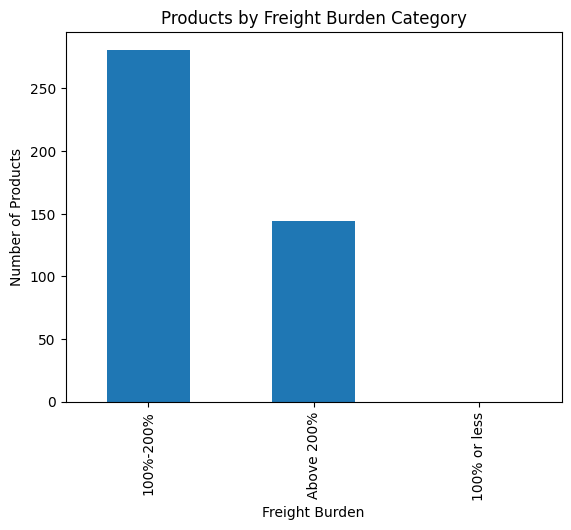

In [74]:
# VISUALIZE FREIGHT BURDEN

product_freight_impact['Burden_Category'].value_counts().plot(
    kind='bar',
    title='Products by Freight Burden Category',
    xlabel='Freight Burden',
    ylabel='Number of Products'
)

In [75]:
# TOP PRODUCTS BY TOTAL FREIGHT COST

print("TOP 15 PRODUCTS BY TOTAL FREIGHT:")
print(
    product_freight_impact
    .sort_values('Total_Freight', ascending=False)
    .head(15)
    .round(2)
)

TOP 15 PRODUCTS BY TOTAL FREIGHT:
                           product_id  Items  Total_Price  Total_Freight  \
300  b60856ce32d90658dbf99b9485327c25     23       207.00         367.48   
46   2083a6feb4bbb31f6abc92fc24e468c0     26       180.00         284.65   
129  51f876eb62be778c757503cf7f8a3b74     18       176.40         282.28   
226  9007d9a8a0d332c61d9dd611fa341f4b     23       180.90         273.14   
298  b59fb744c6f3cd1dc23b10f760848d98     19       188.10         248.54   
148  5dbf50af9485478b933f1028e108640d     12        69.88         198.54   
51   222efa72a47277d611b8b38d71149afd     14        87.90         174.68   
349  d41dc2f2979f52d75d78714b378d4068      9        80.97         170.56   
356  d7205c0ebebe2744d7c2e44b6d69cc95     10        89.90         163.82   
68   2cf9ec82c2ca858baedfb2c2e5c06b6f      9        89.10         159.18   
315  baf25ed4f8f70238cc87230379471454      3        29.70         157.68   
55   2548af3e6e77a690cf3eb6368e9ab61e      9        89

In [76]:
# TOP PRODUCTS BY TOTAL REVENUE

print("TOP 15 PRODUCTS BY TOTAL REVENUE:")
print(
    product_performance
    .sort_values('Total_Revenue', ascending=False)
    .head(15)
    .round(2)
)

TOP 15 PRODUCTS BY TOTAL REVENUE:
                             product_id  Items_Sold  Total_Revenue  Avg_Price  \
24086  bb50f2e236e5eea0100680137654686c         195       63885.00     327.62   
14068  6cdd53843498f92890544667809f1595         156       54730.20     350.83   
27613  d6160fb7873f184099d9bc95e30376af          35       48899.34    1397.12   
27039  d1c427060a0f73f6b889a5c7c61f2ac4         343       47214.51     137.65   
19742  99a4788cb24856965c36a24e339b6058         488       43025.56      88.17   
8051   3dd2a17168ec895c781a9191c1e95ad7         274       41082.60     149.94   
4996   25c38557cf793876c5abdd5931f922db          38       38907.32    1023.88   
12351  5f504b3a1c75b73d6151be81eb05bdc9          63       37733.90     598.95   
10867  53b36df67ebb7c41585e8d54d6772e08         323       37683.42     116.67   
22112  aca2eb7d00ea1a7b8ebd4e68314663af         527       37608.90      71.36   
28970  e0d64dcfaa3b6db5c54ca298ae101d05         194       31786.82     163.

In [77]:
# REVENUE VS FREIGHT ANALYSIS

product_performance['Freight_Ratio_%'] = (
    product_performance['Total_Freight'] /
    product_performance['Total_Revenue']
) * 100

print("AVERAGE FREIGHT AS % OF REVENUE:",
      round(product_performance['Freight_Ratio_%'].mean(), 2))

print("\nTOP 15 PRODUCTS BY FREIGHT % OF REVENUE:")
print(
    product_performance[
        ['product_id', 'Items_Sold', 'Total_Revenue',
         'Total_Freight', 'Freight_Ratio_%']
    ]
    .sort_values('Freight_Ratio_%', ascending=False)
    .head(15)
    .round(2)
)

AVERAGE FREIGHT AS % OF REVENUE: 31.98

TOP 15 PRODUCTS BY FREIGHT % OF REVENUE:
                             product_id  Items_Sold  Total_Revenue  \
17767  8a3254bee785a526d548a81a9bc3c9be           3           2.55   
22656  b07fffe072c9adc235a35d8da7c0584d           1           4.99   
5158   270516a3f41dc035aa87d220228f844c          10          12.00   
700    05b515fdc76e888aada3c6d66c201dff          10          12.00   
5458   29781581fb82fe2389560a3a5331d0ee           3           9.18   
24364  bdbcda578f0215903f8bcd77ca591e0c           1           5.95   
19401  970920a8e74dbbac4bcae9119351d3b7           1           6.99   
24028  baf25ed4f8f70238cc87230379471454           3          29.70   
3044   1716ea399ed8ee62ba811e6f55180f45           3          10.47   
8965   44d53f1240d6332232e4393c06500475           2           6.00   
566    04c4239553c71aafb3b2b5f74f165210           1          25.00   
23779  b91982b3afff5d274cf34ce54801a8e6           1          22.90   
32236  fa

In [78]:
import pandas as pd

products = pd.read_csv(
    '/content/olist_products_dataset1(Cleaned data).csv',
    encoding='latin1'
)

print("PRODUCT DATASET SHAPE:", products.shape)
print("\nPRODUCT COLUMNS:")
print(products.columns.tolist())

PRODUCT DATASET SHAPE: (32951, 10)

PRODUCT COLUMNS:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'Product_Volume_cm3']


In [79]:
print("UNIQUE PRODUCT CATEGORIES:", products['product_category_name'].nunique())

print("\nTOP 15 PRODUCT CATEGORIES:")
print(products['product_category_name'].value_counts().head(15))

UNIQUE PRODUCT CATEGORIES: 73

TOP 15 PRODUCT CATEGORIES:
product_category_name
cama_mesa_banho                3029
esporte_lazer                  2867
moveis_decoracao               2657
beleza_saude                   2444
utilidades_domesticas          2335
automotivo                     1900
informatica_acessorios         1639
brinquedos                     1411
relogios_presentes             1329
telefonia                      1134
bebes                           919
perfumaria                      868
papelaria                       849
fashion_bolsas_e_acessorios     849
cool_stuff                      789
Name: count, dtype: int64


In [80]:
print("MISSING CATEGORY VALUES:", products['product_category_name'].isna().sum())
print("MISSING CATEGORY %:", round(products['product_category_name'].isna().mean() * 100, 2))

MISSING CATEGORY VALUES: 610
MISSING CATEGORY %: 1.85


In [81]:
import os

print(os.listdir('/content'))

['.config', 'product_category_name_translation(Data dictionary).csv', 'olist_customers_dataset 3(Cleaned data) (1).csv', 'olist_order_reviews_dataset(Clean data).csv', 'olist_orders_dataset2(Cleaned data).csv', 'olist_sellers_dataset(Clean data).csv', 'olist_order_items_dataset(Cleaned data).csv', 'olist_products_dataset1(Cleaned data).csv', 'olist_order_payments_dataset(Cleaned data).csv', 'sample_data']


In [82]:
print([f for f in os.listdir('/content') if 'category' in f.lower()])

['product_category_name_translation(Data dictionary).csv']


In [83]:
category_translation = pd.read_csv(
    '/content/product_category_name_translation(Data dictionary).csv',
    encoding='latin1'
)

print("TRANSLATION DATASET SHAPE:", category_translation.shape)
print("\nTRANSLATION COLUMNS:")
print(category_translation.columns.tolist())

print("\nTRANSLATION SAMPLE:")
print(category_translation.head(10))

TRANSLATION DATASET SHAPE: (2, 5)

TRANSLATION COLUMNS:
['Column Name', 'Field Category', 'What It Represents', 'Business Analysis Supported', 'Sample Value']

TRANSLATION SAMPLE:
                     Column Name Field Category  \
0          product_category_name    Categorical   
1  product_category_name_english    Categorical   

                        What It Represents  \
0     Original Portuguese product category   
1  English translation of product category   

                         Business Analysis Supported   Sample Value  
0         Category-level sales and delivery analysis   beleza_saude  
1  Readable category analysis and dashboard repor...  health_beauty  


In [84]:
# CATEGORY-LEVEL PRODUCT DISTRIBUTION

category_summary = (
    products.groupby('product_category_name')
    .agg(
        Product_Count=('product_id', 'count'),
        Avg_Name_Length=('product_name_lenght', 'mean'),
        Avg_Description_Length=('product_description_lenght', 'mean')
    )
    .sort_values('Product_Count', ascending=False)
    .reset_index()
)

print("CATEGORY SUMMARY:")
print(category_summary.head(15).round(2))

CATEGORY SUMMARY:
          product_category_name  Product_Count  Avg_Name_Length  \
0               cama_mesa_banho           3029            51.73   
1                 esporte_lazer           2867            46.96   
2              moveis_decoracao           2657            50.05   
3                  beleza_saude           2444            47.21   
4         utilidades_domesticas           2335            48.02   
5                    automotivo           1900            52.15   
6        informatica_acessorios           1639            47.83   
7                    brinquedos           1411            45.12   
8            relogios_presentes           1329            49.80   
9                     telefonia           1134            50.45   
10                        bebes            919            46.06   
11                   perfumaria            868            45.08   
12                    papelaria            849            49.69   
13  fashion_bolsas_e_acessorios            8

In [85]:
# CATEGORY CONCENTRATION ANALYSIS

category_concentration = category_summary.copy()

category_concentration['Product_Share_%'] = (
    category_concentration['Product_Count']
    / category_concentration['Product_Count'].sum()
    * 100
)

category_concentration['Cumulative_Share_%'] = (
    category_concentration['Product_Share_%'].cumsum()
)

print("TOP 15 CATEGORIES BY PRODUCT SHARE:")
print(
    category_concentration[
        ['product_category_name', 'Product_Count',
         'Product_Share_%', 'Cumulative_Share_%']
    ]
    .head(15)
    .round(2)
)

print(
    "\nTOP 10 CATEGORIES CUMULATIVE SHARE:",
    round(
        category_concentration['Product_Share_%'].head(10).sum(), 2
    ),
    "%"
)

TOP 15 CATEGORIES BY PRODUCT SHARE:
          product_category_name  Product_Count  Product_Share_%  \
0               cama_mesa_banho           3029             9.37   
1                 esporte_lazer           2867             8.86   
2              moveis_decoracao           2657             8.22   
3                  beleza_saude           2444             7.56   
4         utilidades_domesticas           2335             7.22   
5                    automotivo           1900             5.87   
6        informatica_acessorios           1639             5.07   
7                    brinquedos           1411             4.36   
8            relogios_presentes           1329             4.11   
9                     telefonia           1134             3.51   
10                        bebes            919             2.84   
11                   perfumaria            868             2.68   
12                    papelaria            849             2.63   
13  fashion_bolsas_e_acess

In [86]:
# CATEGORY-WISE DESCRIPTION QUALITY

description_analysis = (
    products.groupby('product_category_name')
    .agg(
        Product_Count=('product_id', 'count'),
        Avg_Description_Length=('product_description_lenght', 'mean')
    )
    .sort_values('Avg_Description_Length', ascending=False)
    .reset_index()
)

print("TOP 15 CATEGORIES BY DESCRIPTION LENGTH:")
print(
    description_analysis.head(15).round(2)
)

print("\nOVERALL AVERAGE DESCRIPTION LENGTH:",
      round(products['product_description_lenght'].mean(), 2))

TOP 15 CATEGORIES BY DESCRIPTION LENGTH:
               product_category_name  Product_Count  Avg_Description_Length
0                                pcs             30                 2128.83
1                  moveis_escritorio            309                 1352.77
2                    livros_tecnicos            123                 1351.53
3                       beleza_saude           2444                 1136.93
4                          alimentos             82                 1136.51
5      construcao_ferramentas_jardim             88                 1134.90
6          moveis_colchao_e_estofado             10                 1111.30
7   construcao_ferramentas_seguranca             91                 1105.82
8      industria_comercio_e_negocios             68                 1102.65
9                       dvds_blu_ray             48                 1071.27
10                            musica             27                 1059.96
11                           bebidas           

In [87]:
# PRODUCT ATTRIBUTE COMPLETENESS

print("MISSING VALUES BY PRODUCT ATTRIBUTE:")
print(products.isna().sum().sort_values(ascending=False))

print("\nMISSING VALUE %:")
print(
    (products.isna().mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

MISSING VALUES BY PRODUCT ATTRIBUTE:
product_category_name         610
product_name_lenght           610
product_photos_qty            610
product_description_lenght    610
product_length_cm               2
product_weight_g                2
product_width_cm                2
product_height_cm               2
Product_Volume_cm3              2
product_id                      0
dtype: int64

MISSING VALUE %:
product_category_name         1.85
product_name_lenght           1.85
product_photos_qty            1.85
product_description_lenght    1.85
product_length_cm             0.01
product_weight_g              0.01
product_width_cm              0.01
product_height_cm             0.01
Product_Volume_cm3            0.01
product_id                    0.00
dtype: float64


In [88]:
# INCOMPLETE PRODUCT LISTINGS CHECK

incomplete_products = products[
    products['product_category_name'].isna()
]

print("INCOMPLETE PRODUCT LISTINGS:", len(incomplete_products))

print("\nMISSING VALUES IN THESE LISTINGS:")
print(incomplete_products.isna().sum())

print("\nSAMPLE INCOMPLETE PRODUCTS:")
print(incomplete_products.head(10))

INCOMPLETE PRODUCT LISTINGS: 610

MISSING VALUES IN THESE LISTINGS:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                1
product_length_cm               1
product_height_cm               1
product_width_cm                1
Product_Volume_cm3              1
dtype: int64

SAMPLE INCOMPLETE PRODUCTS:
                           product_id product_category_name  \
105  a41e356c76fab66334f36de622ecbd3a                   NaN   
128  d8dee61c2034d6d075997acef1870e9b                   NaN   
145  56139431d72cd51f19eb9f7dae4d1617                   NaN   
154  46b48281eb6d663ced748f324108c733                   NaN   
197  5fb61f482620cb672f5e586bb132eae9                   NaN   
244  e10758160da97891c2fdcbc35f0f031d                   NaN   
294  39e3b9b12cd0bf8ee681bbc1c130feb5                   NaN   
299  794de06c32a626a5692ff50e4985d36f         

In [89]:
# CHECK WHETHER INCOMPLETE PRODUCTS APPEAR IN ORDERS

# Load order items if not already loaded
import glob
import pandas as pd

order_items_file = glob.glob(
    '/content/olist_order_items_dataset*'
)[0]

order_items = pd.read_csv(
    order_items_file,
    encoding='latin1'
)

# Find the 610 incomplete product IDs
incomplete_product_ids = set(
    incomplete_products['product_id']
)

# Check their order activity
incomplete_order_items = order_items[
    order_items['product_id'].isin(incomplete_product_ids)
]

print("INCOMPLETE PRODUCTS:", len(incomplete_product_ids))
print("ORDER ITEMS FROM INCOMPLETE PRODUCTS:", len(incomplete_order_items))
print(
    "UNIQUE INCOMPLETE PRODUCTS SOLD:",
    incomplete_order_items['product_id'].nunique()
)

print("\nTOTAL SALES VALUE FROM INCOMPLETE PRODUCTS:")

if 'price' in incomplete_order_items.columns:
    print(round(incomplete_order_items['price'].sum(), 2))

print("\nORDER ITEMS COLUMNS:")
print(order_items.columns.tolist())

INCOMPLETE PRODUCTS: 610
ORDER ITEMS FROM INCOMPLETE PRODUCTS: 1603
UNIQUE INCOMPLETE PRODUCTS SOLD: 610

TOTAL SALES VALUE FROM INCOMPLETE PRODUCTS:
179535.28

ORDER ITEMS COLUMNS:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'shipping_limit_time', 'price', 'freight_value']


In [90]:
# BUSINESS IMPACT OF INCOMPLETE PRODUCT RECORDS

total_sales = order_items['price'].sum()
incomplete_sales = incomplete_order_items['price'].sum()

print("TOTAL PRODUCT SALES:", round(total_sales, 2))
print("INCOMPLETE PRODUCT SALES:", round(incomplete_sales, 2))

print(
    "INCOMPLETE PRODUCT SALES SHARE:",
    round((incomplete_sales / total_sales) * 100, 2),
    "%"
)

TOTAL PRODUCT SALES: 13591643.7
INCOMPLETE PRODUCT SALES: 179535.28
INCOMPLETE PRODUCT SALES SHARE: 1.32 %


In [91]:
# HANDLE MISSING PRODUCT CATEGORIES

products['product_category_name'] = (
    products['product_category_name']
    .fillna('Unknown')
)

print("Missing categories after treatment:",
      products['product_category_name'].isna().sum())

print("\nUpdated category distribution:")
print(products['product_category_name'].value_counts().head(15))

Missing categories after treatment: 0

Updated category distribution:
product_category_name
cama_mesa_banho                3029
esporte_lazer                  2867
moveis_decoracao               2657
beleza_saude                   2444
utilidades_domesticas          2335
automotivo                     1900
informatica_acessorios         1639
brinquedos                     1411
relogios_presentes             1329
telefonia                      1134
bebes                           919
perfumaria                      868
papelaria                       849
fashion_bolsas_e_acessorios     849
cool_stuff                      789
Name: count, dtype: int64


In [92]:
print("UNKNOWN PRODUCTS:",
      (products['product_category_name'] == 'Unknown').sum())

print("\nUNKNOWN PRODUCT SHARE:",
      round(
          (products['product_category_name'] == 'Unknown').mean() * 100,
          2
      ),
      "%")

UNKNOWN PRODUCTS: 610

UNKNOWN PRODUCT SHARE: 1.85 %


In [93]:
# ==========================================
# PRODUCT CATEGORY SALES ANALYSIS
# ==========================================

# Merge product category information with transaction data
category_sales = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

print("CATEGORY SALES DATASET SHAPE:", category_sales.shape)

print("\nCATEGORY SALES COLUMNS:")
print(category_sales.columns.tolist())

print("\nSAMPLE:")
print(category_sales.head())

CATEGORY SALES DATASET SHAPE: (112650, 9)

CATEGORY SALES COLUMNS:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'shipping_limit_time', 'price', 'freight_value', 'product_category_name']

SAMPLE:
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

  ship

In [94]:
category_performance = category_sales.groupby(
    'product_category_name'
).agg(
    Revenue=('price', 'sum'),
    Units_Sold=('product_id', 'count'),
    Orders=('order_id', 'nunique'),
    Freight=('freight_value', 'sum')
).reset_index()

category_performance = category_performance.sort_values(
    'Revenue', ascending=False
)

print("TOP 15 CATEGORIES BY REVENUE:")
print(category_performance.head(15).round(2))

TOP 15 CATEGORIES BY REVENUE:
     product_category_name     Revenue  Units_Sold  Orders    Freight
12            beleza_saude  1258681.34        9670    8836  182566.73
67      relogios_presentes  1205005.68        5991    5624  100535.93
14         cama_mesa_banho  1036988.68       11115    9417  204693.04
33           esporte_lazer   988048.97        8641    7720  168607.51
45  informatica_acessorios   911954.32        7827    6689  147318.08
55        moveis_decoracao   729762.49        8334    6449  172749.30
27              cool_stuff   635290.85        3796    3632   84039.10
73   utilidades_domesticas   632248.66        6964    5884  146149.11
9               automotivo   592720.11        4235    3897   92664.21
41      ferramentas_jardim   485256.46        4347    3518   98962.75
13              brinquedos   483946.60        4117    3886   77425.95
10                   bebes   411764.89        3065    2885   68353.11
63              perfumaria   399124.87        3419    3162  

In [95]:
category_performance['Revenue_Share_%'] = (
    category_performance['Revenue']
    / category_performance['Revenue'].sum()
    * 100
)

category_performance['Cumulative_Revenue_Share_%'] = (
    category_performance['Revenue_Share_%'].cumsum()
)

print("TOP 15 CATEGORIES BY REVENUE SHARE:")
print(
    category_performance[
        ['product_category_name', 'Revenue', 'Revenue_Share_%',
         'Cumulative_Revenue_Share_%']
    ].head(15).round(2)
)

TOP 15 CATEGORIES BY REVENUE SHARE:
     product_category_name     Revenue  Revenue_Share_%  \
12            beleza_saude  1258681.34             9.26   
67      relogios_presentes  1205005.68             8.87   
14         cama_mesa_banho  1036988.68             7.63   
33           esporte_lazer   988048.97             7.27   
45  informatica_acessorios   911954.32             6.71   
55        moveis_decoracao   729762.49             5.37   
27              cool_stuff   635290.85             4.67   
73   utilidades_domesticas   632248.66             4.65   
9               automotivo   592720.11             4.36   
41      ferramentas_jardim   485256.46             3.57   
13              brinquedos   483946.60             3.56   
10                   bebes   411764.89             3.03   
63              perfumaria   399124.87             2.94   
71               telefonia   323667.53             2.38   
56       moveis_escritorio   273960.70             2.02   

    Cumulative_Reve

In [96]:
category_performance['Avg_Order_Value'] = (
    category_performance['Revenue']
    / category_performance['Orders']
)

print("TOP 15 CATEGORIES BY AVERAGE ORDER VALUE:")
print(
    category_performance[
        ['product_category_name', 'Revenue', 'Orders', 'Avg_Order_Value']
    ].sort_values('Avg_Order_Value', ascending=False)
    .head(15)
    .round(2)
)

TOP 15 CATEGORIES BY AVERAGE ORDER VALUE:
                            product_category_name     Revenue  Orders  \
62                                            pcs   222963.13     181   
65                    portateis_casa_forno_e_cafe    47445.71      75   
30                             eletrodomesticos_2   113317.74     234   
1                       agro_industria_e_comercio    72530.47     182   
46                          instrumentos_musicais   191498.88     628   
32                                eletroportateis   190648.58     630   
66  portateis_cozinha_e_preparadores_de_alimentos     3968.53      14   
72                                 telefonia_fixa    59583.00     217   
26               construcao_ferramentas_seguranca    40544.52     167   
20                                   climatizacao    55024.96     253   
56                              moveis_escritorio   273960.70    1273   
67                             relogios_presentes  1205005.68    5624   
57       

In [97]:
print("TOP CATEGORIES BY REVENUE + ORDER VOLUME:")

print(
    category_performance[
        ['product_category_name', 'Revenue', 'Units_Sold',
         'Orders', 'Avg_Order_Value']
    ]
    .sort_values('Revenue', ascending=False)
    .head(15)
    .round(2)
)

TOP CATEGORIES BY REVENUE + ORDER VOLUME:
     product_category_name     Revenue  Units_Sold  Orders  Avg_Order_Value
12            beleza_saude  1258681.34        9670    8836           142.45
67      relogios_presentes  1205005.68        5991    5624           214.26
14         cama_mesa_banho  1036988.68       11115    9417           110.12
33           esporte_lazer   988048.97        8641    7720           127.99
45  informatica_acessorios   911954.32        7827    6689           136.34
55        moveis_decoracao   729762.49        8334    6449           113.16
27              cool_stuff   635290.85        3796    3632           174.91
73   utilidades_domesticas   632248.66        6964    5884           107.45
9               automotivo   592720.11        4235    3897           152.10
41      ferramentas_jardim   485256.46        4347    3518           137.94
13              brinquedos   483946.60        4117    3886           124.54
10                   bebes   411764.89        

In [98]:
seller_performance = category_sales.groupby(
    'seller_id'
).agg(
    Revenue=('price', 'sum'),
    Units_Sold=('product_id', 'count'),
    Orders=('order_id', 'nunique'),
    Freight=('freight_value', 'sum')
).reset_index()

seller_performance = seller_performance.sort_values(
    'Revenue', ascending=False
)

print("TOP 15 SELLERS BY REVENUE:")
print(
    seller_performance.head(15).round(2)
)

TOP 15 SELLERS BY REVENUE:
                             seller_id    Revenue  Units_Sold  Orders  \
857   4869f7a5dfa277a7dca6462dcf3b52b2  229472.63        1156    1132   
1013  53243585a1d6dc2643021fd1853d8905  222776.05         410     358   
881   4a3ca9315b744ce9f8e9374361493884  200472.92        1987    1806   
3024  fa1c13f2614d7b5c4749cbc52fecda94  194042.03         586     585   
1535  7c67e1448b00f6e969d365cea6b010ab  187923.89        1364     982   
1560  7e93a43ef30c4f03f38b393420bc753a  176431.87         340     336   
2643  da8622b14eb17ae2831f4ac5b9dab84a  160236.57        1551    1314   
1505  7a67c85e85bb2ce8582c35f2203ad736  141745.53        1171    1160   
192   1025f0e2d44d7041d6cf58b6550e0bfa  138968.55        1428     915   
1824  955fee9216a65b617aa5c0531780ce60  135171.70        1499    1287   
843   46dc3b2cc0980fb8ec44634e21d2718e  128111.19         542     521   
1235  6560211a19b47992c3666cc44a7e94c0  123304.83        2033    1854   
1198  620c87c171fb2a6dd6

In [99]:
total_seller_revenue = seller_performance['Revenue'].sum()

seller_performance['Revenue_Share_%'] = (
    seller_performance['Revenue'] / total_seller_revenue * 100
).round(2)

seller_performance['Cumulative_Revenue_Share_%'] = (
    seller_performance['Revenue_Share_%'].cumsum()
).round(2)

print("TOP 15 SELLERS BY REVENUE SHARE:")
print(
    seller_performance[
        ['seller_id', 'Revenue', 'Revenue_Share_%',
         'Cumulative_Revenue_Share_%']
    ].head(15)
)

TOP 15 SELLERS BY REVENUE SHARE:
                             seller_id    Revenue  Revenue_Share_%  \
857   4869f7a5dfa277a7dca6462dcf3b52b2  229472.63             1.69   
1013  53243585a1d6dc2643021fd1853d8905  222776.05             1.64   
881   4a3ca9315b744ce9f8e9374361493884  200472.92             1.47   
3024  fa1c13f2614d7b5c4749cbc52fecda94  194042.03             1.43   
1535  7c67e1448b00f6e969d365cea6b010ab  187923.89             1.38   
1560  7e93a43ef30c4f03f38b393420bc753a  176431.87             1.30   
2643  da8622b14eb17ae2831f4ac5b9dab84a  160236.57             1.18   
1505  7a67c85e85bb2ce8582c35f2203ad736  141745.53             1.04   
192   1025f0e2d44d7041d6cf58b6550e0bfa  138968.55             1.02   
1824  955fee9216a65b617aa5c0531780ce60  135171.70             0.99   
843   46dc3b2cc0980fb8ec44634e21d2718e  128111.19             0.94   
1235  6560211a19b47992c3666cc44a7e94c0  123304.83             0.91   
1198  620c87c171fb2a6dd6e8bb4dec959fc6  114774.50        

In [100]:
seller_performance['Avg_Order_Value'] = (
    seller_performance['Revenue'] / seller_performance['Orders']
).round(2)

print("TOP 15 SELLERS BY AVERAGE ORDER VALUE:")
print(
    seller_performance[
        ['seller_id', 'Revenue', 'Units_Sold', 'Orders',
         'Avg_Order_Value']
    ]
    .sort_values('Avg_Order_Value', ascending=False)
    .head(15)
)

TOP 15 SELLERS BY AVERAGE ORDER VALUE:
                             seller_id   Revenue  Units_Sold  Orders  \
1583  80ceebb4ee9b31afb6c6a916a574a1e2   6729.00           1       1   
2881  ee27a8f15b1dded4d213a468ba4eb391   6499.00           1       1   
2157  b37c4c02bda3161a7546a4e6d222d5b2  24075.00          15       4   
1078  585175ec331ea177fa47199e39a6170a   3549.00           1       1   
2073  abe021b01ba992245271b9aa422032df   6720.00           2       2   
1943  a00824eb9093d40e589b940ec45c4eb0   9399.97           3       3   
2730  e2a1ac9bf33e5549a2a4f834e70df2f8  14999.45           5       5   
2813  e908c0f3646e8b60375734a350d95d71   2951.00           1       1   
2589  d63c73efd41eb002280e7ec831424edb   5598.00           2       2   
238   1444c08e64d55fb3c25f0f09c07ffcf2   2749.00           1       1   
42    039e6ad9dae79614493083e241147386  12925.00           5       5   
1835  961dff0a659b4561334372337dd897d9   9946.00           4       4   
2314  c004e5ea15737026cec

In [101]:
print("CUSTOMER DATASET SHAPE:", customers.shape)
print("\nCUSTOMER COLUMNS:")
print(customers.columns.tolist())
print("\nCUSTOMER SAMPLE:")
print(customers.head())

CUSTOMER DATASET SHAPE: (99441, 6)

CUSTOMER COLUMNS:
['customer_id', 'customer_unique_id', 'Customer segment', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

CUSTOMER SAMPLE:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

  Customer segment  customer_zip_code_prefix          customer_city  \
0     New Customer                     14409                 franca   
1     New Customer                      9790  sao bernardo do campo   
2     New Customer                      1151              sao paulo   
3     New Customer                      8775        mogi das cruzes   
4  Repeat Cus

In [102]:
print("CUSTOMER SEGMENT DISTRIBUTION:")
print(customers['Customer segment'].value_counts())

print("\nCUSTOMER SEGMENT SHARE:")
print(
    (customers['Customer segment'].value_counts(normalize=True) * 100)
    .round(2)
)

CUSTOMER SEGMENT DISTRIBUTION:
Customer segment
New Customer       93099
Repeat Customer     6342
Name: count, dtype: int64

CUSTOMER SEGMENT SHARE:
Customer segment
New Customer       93.62
Repeat Customer     6.38
Name: proportion, dtype: float64


In [103]:
# CUSTOMER-LEVEL SALES DATA

customer_sales = (
    order_items
    .merge(
        orders[['order_id', 'customer_id']],
        on='order_id',
        how='left'
    )
    .merge(
        customers[['customer_id', 'Customer segment']],
        on='customer_id',
        how='left'
    )
)

print("CUSTOMER SALES SHAPE:", customer_sales.shape)
print("\nCUSTOMER SALES COLUMNS:")
print(customer_sales.columns.tolist())

CUSTOMER SALES SHAPE: (112650, 10)

CUSTOMER SALES COLUMNS:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'shipping_limit_time', 'price', 'freight_value', 'customer_id', 'Customer segment']


In [104]:
segment_revenue = (
    customer_sales
    .groupby('Customer segment')
    .agg(
        Revenue=('price', 'sum'),
        Units_Sold=('order_item_id', 'count'),
        Orders=('order_id', 'nunique')
    )
)

segment_revenue['Revenue_Share_%'] = (
    segment_revenue['Revenue']
    / segment_revenue['Revenue'].sum() * 100
).round(2)

print("REVENUE BY CUSTOMER SEGMENT:")
print(segment_revenue.round(2))

REVENUE BY CUSTOMER SEGMENT:
                      Revenue  Units_Sold  Orders  Revenue_Share_%
Customer segment                                                  
New Customer      12723330.54      105444   92370            93.61
Repeat Customer     868313.16        7206    6296             6.39


In [105]:
segment_aov = (
    customer_sales
    .groupby('Customer segment')
    .agg(
        Revenue=('price', 'sum'),
        Orders=('order_id', 'nunique')
    )
)

segment_aov['Avg_Order_Value'] = (
    segment_aov['Revenue'] / segment_aov['Orders']
).round(2)

print("AVERAGE ORDER VALUE BY CUSTOMER SEGMENT:")
print(segment_aov.round(2))

AVERAGE ORDER VALUE BY CUSTOMER SEGMENT:
                      Revenue  Orders  Avg_Order_Value
Customer segment                                      
New Customer      12723330.54   92370           137.74
Repeat Customer     868313.16    6296           137.92


In [106]:
segment_frequency = (
    customer_sales
    .groupby('Customer segment')
    .agg(
        Unique_Customers=('customer_id', 'nunique'),
        Orders=('order_id', 'nunique')
    )
)

segment_frequency['Orders_per_Customer'] = (
    segment_frequency['Orders'] /
    segment_frequency['Unique_Customers']
).round(2)

print("ORDER FREQUENCY BY CUSTOMER SEGMENT:")
print(segment_frequency)

ORDER FREQUENCY BY CUSTOMER SEGMENT:
                  Unique_Customers  Orders  Orders_per_Customer
Customer segment                                               
New Customer                 92370   92370                  1.0
Repeat Customer               6296    6296                  1.0


In [107]:
# TRUE ORDER FREQUENCY BY CUSTOMER

customer_order_frequency = (
    orders
    .merge(
        customers[['customer_id', 'Customer segment']],
        on='customer_id',
        how='left'
    )
    .groupby(['Customer segment', 'customer_id'])
    .agg(
        Orders=('order_id', 'nunique')
    )
    .reset_index()
)

segment_frequency_correct = (
    customer_order_frequency
    .groupby('Customer segment')
    .agg(
        Unique_Customers=('customer_id', 'nunique'),
        Total_Orders=('Orders', 'sum'),
        Avg_Orders_Per_Customer=('Orders', 'mean')
    )
    .round(2)
)

print("TRUE ORDER FREQUENCY BY CUSTOMER SEGMENT:")
print(segment_frequency_correct)

TRUE ORDER FREQUENCY BY CUSTOMER SEGMENT:
                  Unique_Customers  Total_Orders  Avg_Orders_Per_Customer
Customer segment                                                         
New Customer                 93099         93099                      1.0
Repeat Customer               6342          6342                      1.0


In [108]:
# TRUE CUSTOMER ORDER FREQUENCY
# Using customer_unique_id to identify the same customer

customer_orders = (
    orders
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
    .groupby('customer_unique_id')
    .agg(
        Total_Orders=('order_id', 'nunique')
    )
    .reset_index()
)

customer_orders['Customer segment'] = customer_orders['Total_Orders'].apply(
    lambda x: 'New Customer' if x == 1 else 'Repeat Customer'
)

print("CUSTOMER ORDER FREQUENCY:")
print(customer_orders['Customer segment'].value_counts())

print("\nAVERAGE ORDERS PER CUSTOMER:")
print(
    customer_orders
    .groupby('Customer segment')['Total_Orders']
    .mean()
    .round(2)
)

CUSTOMER ORDER FREQUENCY:
Customer segment
New Customer       93099
Repeat Customer     2997
Name: count, dtype: int64

AVERAGE ORDERS PER CUSTOMER:
Customer segment
New Customer       1.00
Repeat Customer    2.12
Name: Total_Orders, dtype: float64


In [109]:
repeat_customer_rate = (
    (customer_orders['Customer segment'] == 'Repeat Customer').mean() * 100
)

print("REPEAT CUSTOMER RATE:",
      round(repeat_customer_rate, 2), "%")

REPEAT CUSTOMER RATE: 3.12 %


In [110]:
# REVENUE CONTRIBUTION BY CUSTOMER TYPE

customer_revenue = (
    orders
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
    .merge(
        order_items[['order_id', 'price']],
        on='order_id',
        how='inner'
    )
    .groupby('customer_unique_id')
    .agg(Revenue=('price', 'sum'))
    .reset_index()
    .merge(
        customer_orders[['customer_unique_id', 'Customer segment']],
        on='customer_unique_id',
        how='left'
    )
)

segment_revenue = (
    customer_revenue
    .groupby('Customer segment')
    .agg(
        Customers=('customer_unique_id', 'nunique'),
        Revenue=('Revenue', 'sum')
    )
)

segment_revenue['Revenue_Share_%'] = (
    segment_revenue['Revenue'] /
    segment_revenue['Revenue'].sum() * 100
).round(2)

print("REVENUE CONTRIBUTION BY CUSTOMER SEGMENT:")
print(segment_revenue.round(2))

REVENUE CONTRIBUTION BY CUSTOMER SEGMENT:
                  Customers      Revenue  Revenue_Share_%
Customer segment                                         
New Customer          92431  12812821.73            94.27
Repeat Customer        2989    778821.97             5.73


In [111]:
# MONTHLY REVENUE TREND

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

monthly_revenue = (
    order_items
    .merge(
        orders[['order_id', 'order_purchase_timestamp']],
        on='order_id',
        how='inner'
    )
    .assign(
        Month=lambda x: x['order_purchase_timestamp'].dt.to_period('M').astype(str)
    )
    .groupby('Month')
    .agg(
        Revenue=('price', 'sum'),
        Orders=('order_id', 'nunique')
    )
    .reset_index()
)

print("MONTHLY REVENUE TREND:")
print(monthly_revenue.round(2))

MONTHLY REVENUE TREND:
      Month     Revenue  Orders
0   2016-09      267.36       3
1   2016-10    49507.66     308
2   2016-12       10.90       1
3   2017-01   120312.87     789
4   2017-02   247303.02    1733
5   2017-03   374344.30    2641
6   2017-04   359927.23    2391
7   2017-05   506071.14    3660
8   2017-06   433038.60    3217
9   2017-07   498031.48    3969
10  2017-08   573971.68    4293
11  2017-09   624401.69    4243
12  2017-10   664219.43    4568
13  2017-11  1010271.37    7451
14  2017-12   743914.17    5624
15  2018-01   950030.36    7220
16  2018-02   844178.71    6694
17  2018-03   983213.44    7188
18  2018-04   996647.75    6934
19  2018-05   996517.68    6853
20  2018-06   865124.31    6160
21  2018-07   895507.22    6273
22  2018-08   854686.33    6452
23  2018-09      145.00       1


In [112]:
# MONTH-ON-MONTH REVENUE GROWTH

monthly_revenue['Revenue_Growth_%'] = (
    monthly_revenue['Revenue']
    .pct_change() * 100
).round(2)

print("MONTHLY REVENUE WITH GROWTH:")
print(monthly_revenue.round(2))

MONTHLY REVENUE WITH GROWTH:
      Month     Revenue  Orders  Revenue_Growth_%
0   2016-09      267.36       3               NaN
1   2016-10    49507.66     308          18417.23
2   2016-12       10.90       1            -99.98
3   2017-01   120312.87     789        1103687.80
4   2017-02   247303.02    1733            105.55
5   2017-03   374344.30    2641             51.37
6   2017-04   359927.23    2391             -3.85
7   2017-05   506071.14    3660             40.60
8   2017-06   433038.60    3217            -14.43
9   2017-07   498031.48    3969             15.01
10  2017-08   573971.68    4293             15.25
11  2017-09   624401.69    4243              8.79
12  2017-10   664219.43    4568              6.38
13  2017-11  1010271.37    7451             52.10
14  2017-12   743914.17    5624            -26.36
15  2018-01   950030.36    7220             27.71
16  2018-02   844178.71    6694            -11.14
17  2018-03   983213.44    7188             16.47
18  2018-04   996647.

In [113]:
# PEAK AND LOW REVENUE MONTHS
# Exclude very low-volume months to avoid partial-month distortion

meaningful_months = monthly_revenue[
    monthly_revenue['Orders'] >= 1000
].copy()

peak_month = meaningful_months.loc[
    meaningful_months['Revenue'].idxmax()
]

lowest_month = meaningful_months.loc[
    meaningful_months['Revenue'].idxmin()
]

print("PEAK REVENUE MONTH:")
print(peak_month)

print("\nLOWEST MEANINGFUL REVENUE MONTH:")
print(lowest_month)

PEAK REVENUE MONTH:
Month                  2017-11
Revenue             1010271.37
Orders                    7451
Revenue_Growth_%          52.1
Name: 13, dtype: object

LOWEST MEANINGFUL REVENUE MONTH:
Month                 2017-02
Revenue             247303.02
Orders                   1733
Revenue_Growth_%       105.55
Name: 4, dtype: object


In [114]:
# BEST AND WORST MEANINGFUL MONTH-ON-MONTH GROWTH

growth_months = monthly_revenue[
    monthly_revenue['Orders'] >= 1000
].dropna(subset=['Revenue_Growth_%'])

best_growth = growth_months.loc[
    growth_months['Revenue_Growth_%'].idxmax()
]

worst_growth = growth_months.loc[
    growth_months['Revenue_Growth_%'].idxmin()
]

print("BEST MEANINGFUL MoM GROWTH:")
print(best_growth[['Month', 'Revenue', 'Orders', 'Revenue_Growth_%']])

print("\nWORST MEANINGFUL MoM GROWTH:")
print(worst_growth[['Month', 'Revenue', 'Orders', 'Revenue_Growth_%']])

BEST MEANINGFUL MoM GROWTH:
Month                 2017-02
Revenue             247303.02
Orders                   1733
Revenue_Growth_%       105.55
Name: 4, dtype: object

WORST MEANINGFUL MoM GROWTH:
Month                 2017-12
Revenue             743914.17
Orders                   5624
Revenue_Growth_%       -26.36
Name: 14, dtype: object


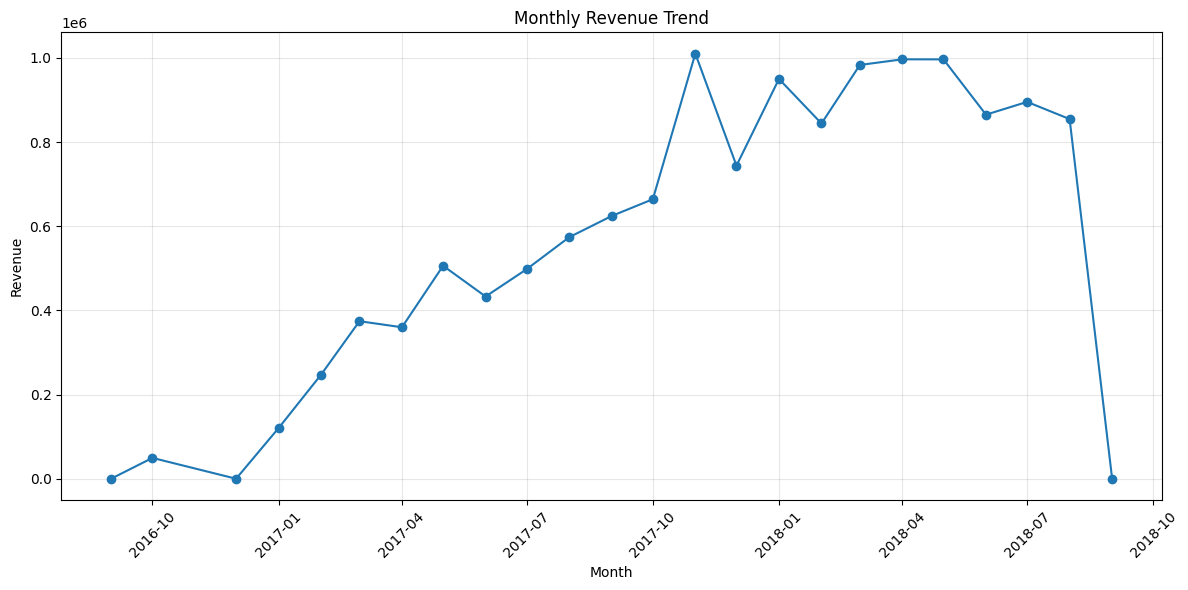

In [115]:
import matplotlib.pyplot as plt

# Convert Month to datetime for proper chronological plotting
monthly_revenue['Month'] = pd.to_datetime(monthly_revenue['Month'])

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue['Month'],
    monthly_revenue['Revenue'],
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

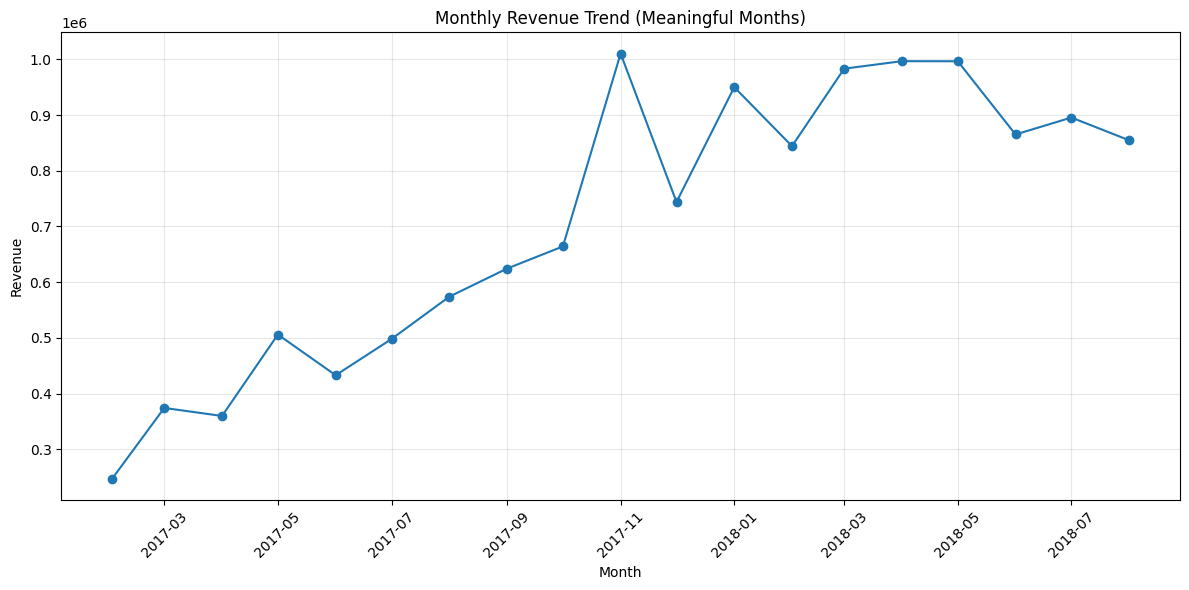

In [116]:
# CLEAN MONTHLY REVENUE TREND
# Exclude low-volume/partial months

monthly_revenue_clean = monthly_revenue[
    monthly_revenue['Orders'] >= 1000
].copy()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue_clean['Month'],
    monthly_revenue_clean['Revenue'],
    marker='o'
)

plt.title('Monthly Revenue Trend (Meaningful Months)')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

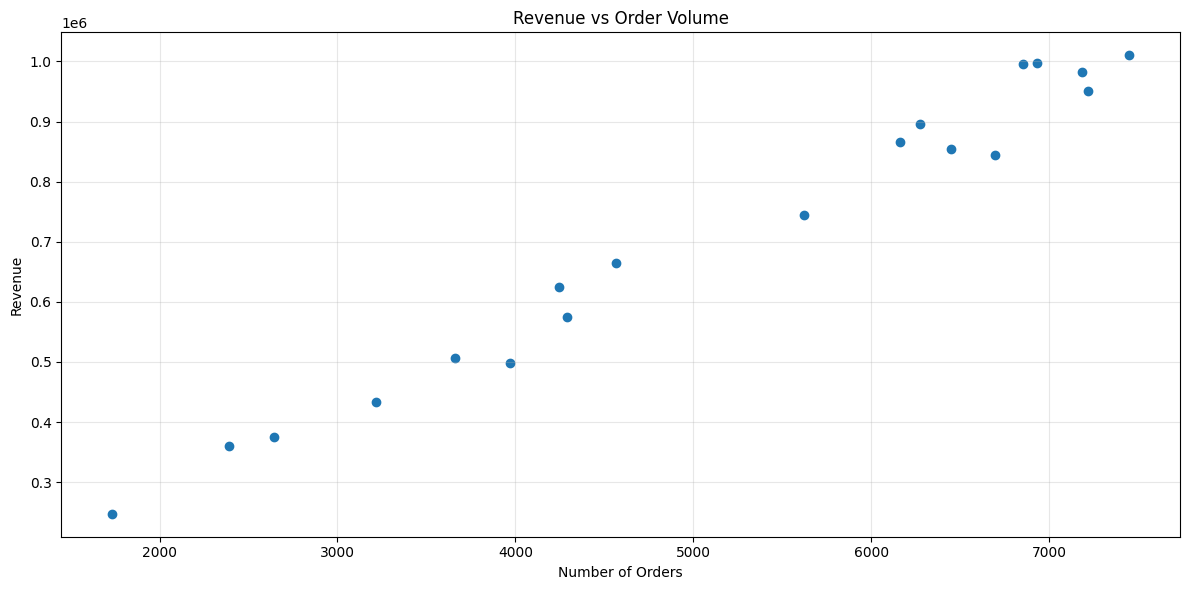

In [117]:
# MONTHLY REVENUE VS ORDER VOLUME

plt.figure(figsize=(12, 6))

plt.scatter(
    monthly_revenue_clean['Orders'],
    monthly_revenue_clean['Revenue']
)

plt.title('Revenue vs Order Volume')
plt.xlabel('Number of Orders')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [118]:
# CORRELATION BETWEEN ORDERS AND REVENUE

correlation = monthly_revenue_clean[
    ['Orders', 'Revenue']
].corr().loc['Orders', 'Revenue']

print("Correlation between Orders and Revenue:", round(correlation, 3))

Correlation between Orders and Revenue: 0.99


In [119]:
# MONTHLY AVERAGE ORDER VALUE

monthly_revenue_clean['AOV'] = (
    monthly_revenue_clean['Revenue'] /
    monthly_revenue_clean['Orders']
).round(2)

print("MONTHLY REVENUE, ORDERS & AOV:")
print(
    monthly_revenue_clean[
        ['Month', 'Revenue', 'Orders', 'AOV']
    ].round(2)
)

MONTHLY REVENUE, ORDERS & AOV:
        Month     Revenue  Orders     AOV
4  2017-02-01   247303.02    1733  142.70
5  2017-03-01   374344.30    2641  141.74
6  2017-04-01   359927.23    2391  150.53
7  2017-05-01   506071.14    3660  138.27
8  2017-06-01   433038.60    3217  134.61
9  2017-07-01   498031.48    3969  125.48
10 2017-08-01   573971.68    4293  133.70
11 2017-09-01   624401.69    4243  147.16
12 2017-10-01   664219.43    4568  145.41
13 2017-11-01  1010271.37    7451  135.59
14 2017-12-01   743914.17    5624  132.27
15 2018-01-01   950030.36    7220  131.58
16 2018-02-01   844178.71    6694  126.11
17 2018-03-01   983213.44    7188  136.79
18 2018-04-01   996647.75    6934  143.73
19 2018-05-01   996517.68    6853  145.41
20 2018-06-01   865124.31    6160  140.44
21 2018-07-01   895507.22    6273  142.76
22 2018-08-01   854686.33    6452  132.47


In [120]:
# CORRELATION: AOV VS REVENUE

aov_revenue_corr = monthly_revenue_clean[
    ['AOV', 'Revenue']
].corr().loc['AOV', 'Revenue']

aov_orders_corr = monthly_revenue_clean[
    ['AOV', 'Orders']
].corr().loc['AOV', 'Orders']

print("AOV vs Revenue Correlation:", round(aov_revenue_corr, 3))
print("AOV vs Orders Correlation:", round(aov_orders_corr, 3))

AOV vs Revenue Correlation: -0.157
AOV vs Orders Correlation: -0.287


In [121]:
customer_order_check = (
    customer_sales
    .groupby('customer_id')
    .agg(
        Total_Orders=('order_id', 'nunique'),
        Customer_segment=('Customer segment', 'first')
    )
    .reset_index()
)

print(customer_order_check['Customer_segment'].value_counts())

print("\nOrder count distribution:")
print(customer_order_check['Total_Orders'].value_counts().sort_index())

Customer_segment
New Customer       92370
Repeat Customer     6296
Name: count, dtype: int64

Order count distribution:
Total_Orders
1    98666
Name: count, dtype: int64


In [122]:
print(customer_sales.columns.tolist())

['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'shipping_limit_time', 'price', 'freight_value', 'customer_id', 'Customer segment']


In [123]:
customer_sales = customer_sales.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

print(customer_sales[['customer_id', 'customer_unique_id']].head())

                        customer_id                customer_unique_id
0  3ce436f183e68e07877b285a838db11a  871766c5855e863f6eccc05f988b23cb
1  f6dd3ec061db4e3987629fe6b26e5cce  eb28e67c4c0b83846050ddfb8a35d051
2  6489ae5e4333f3693df5ad4372dab6d3  3818d81c6709e39d06b2738a8d3a2474
3  d4eb9395c8c0431ee92fce09860c5a06  af861d436cfc08b2c2ddefd0ba074622
4  58dbd0b2d70206bf40e62cd34e84d795  64b576fb70d441e8f1b2d7d446e483c5


In [124]:
unique_customer_orders = (
    customer_sales
    .groupby('customer_unique_id')
    .agg(
        Total_Orders=('order_id', 'nunique')
    )
    .reset_index()
)

print("ORDER COUNT PER UNIQUE CUSTOMER:")
print(
    unique_customer_orders['Total_Orders']
    .value_counts()
    .sort_index()
)

ORDER COUNT PER UNIQUE CUSTOMER:
Total_Orders
1     92507
2      2673
3       192
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64


In [125]:
repeat_customers = (
    unique_customer_orders['Total_Orders'] > 1
).sum()

total_unique_customers = len(unique_customer_orders)

repeat_customer_rate = (
    repeat_customers / total_unique_customers * 100
)

print("Repeat Customer Rate:", round(repeat_customer_rate, 2), "%")

Repeat Customer Rate: 3.05 %


In [127]:
unique_customer_orders['Customer_segment'] = unique_customer_orders['Total_Orders'].apply(
    lambda x: 'New Customer' if x == 1 else 'Repeat Customer'
)

print(unique_customer_orders['Customer_segment'].value_counts())

Customer_segment
New Customer       92507
Repeat Customer     2913
Name: count, dtype: int64


In [128]:
avg_orders_segment = (
    unique_customer_orders
    .groupby('Customer_segment')['Total_Orders']
    .mean()
    .round(2)
)

print("AVERAGE ORDERS PER CUSTOMER:")
print(avg_orders_segment)

AVERAGE ORDERS PER CUSTOMER:
Customer_segment
New Customer       1.00
Repeat Customer    2.11
Name: Total_Orders, dtype: float64


In [130]:
segment_revenue = (
    customer_sales
    .groupby('Customer segment')['price']
    .sum()
)

revenue_share = (
    segment_revenue / segment_revenue.sum() * 100
).round(2)

print("REVENUE SHARE BY CUSTOMER SEGMENT:")
print(revenue_share)

REVENUE SHARE BY CUSTOMER SEGMENT:
Customer segment
New Customer       93.61
Repeat Customer     6.39
Name: price, dtype: float64


In [131]:
aov_segment = (
    customer_sales
    .groupby('Customer segment')['price']
    .sum()
    /
    customer_sales
    .groupby('Customer segment')['order_id'].nunique()
).round(2)

print("AOV BY CUSTOMER SEGMENT:")
print(aov_segment)

AOV BY CUSTOMER SEGMENT:
Customer segment
New Customer       137.74
Repeat Customer    137.92
dtype: float64


In [132]:
monthly_revenue_clean = (
    customer_sales
    .assign(Month=pd.to_datetime(customer_sales['shipping_limit_date']).dt.to_period('M').astype(str))
    .groupby('Month')
    .agg(
        Revenue=('price', 'sum'),
        Orders=('order_id', 'nunique')
    )
    .reset_index()
)

print("MONTHLY REVENUE & ORDERS:")
print(monthly_revenue_clean.round(2))

MONTHLY REVENUE & ORDERS:
      Month     Revenue  Orders
0   2016-09      194.47       2
1   2016-10    49580.55     309
2   2016-12       10.90       1
3   2017-01    80124.74     573
4   2017-02   245982.01    1650
5   2017-03   343242.60    2401
6   2017-04   308148.32    2111
7   2017-05   505655.46    3674
8   2017-06   469001.05    3385
9   2017-07   465282.10    3643
10  2017-08   560093.34    4403
11  2017-09   617046.12    4165
12  2017-10   658020.23    4490
13  2017-11   883351.63    6314
14  2017-12   898920.98    6772
15  2018-01   845279.18    6656
16  2018-02   819228.85    6450
17  2018-03  1030527.84    7636
18  2018-04   958729.70    6656
19  2018-05  1084358.55    7572
20  2018-06   870736.84    6019
21  2018-07   811132.08    5922
22  2018-08  1072147.70    7823
23  2018-09    14502.50      82
24  2020-02      145.98       2
25  2020-04      199.98       1


In [133]:
meaningful_months = monthly_revenue_clean[
    (monthly_revenue_clean['Month'] >= '2017-02') &
    (monthly_revenue_clean['Month'] <= '2018-08')
].copy()

print("MEANINGFUL MONTHS:")
print(meaningful_months)

MEANINGFUL MONTHS:
      Month     Revenue  Orders
4   2017-02   245982.01    1650
5   2017-03   343242.60    2401
6   2017-04   308148.32    2111
7   2017-05   505655.46    3674
8   2017-06   469001.05    3385
9   2017-07   465282.10    3643
10  2017-08   560093.34    4403
11  2017-09   617046.12    4165
12  2017-10   658020.23    4490
13  2017-11   883351.63    6314
14  2017-12   898920.98    6772
15  2018-01   845279.18    6656
16  2018-02   819228.85    6450
17  2018-03  1030527.84    7636
18  2018-04   958729.70    6656
19  2018-05  1084358.55    7572
20  2018-06   870736.84    6019
21  2018-07   811132.08    5922
22  2018-08  1072147.70    7823


In [135]:
segment_revenue = (
    customer_sales
    .groupby('Customer segment')['price']
    .sum()
)

revenue_share = (
    segment_revenue / segment_revenue.sum() * 100
).round(2)

print("REVENUE SHARE BY CUSTOMER SEGMENT:")
print(revenue_share)

REVENUE SHARE BY CUSTOMER SEGMENT:
Customer segment
New Customer       93.61
Repeat Customer     6.39
Name: price, dtype: float64


In [136]:
aov_segment = (
    customer_sales
    .groupby('Customer segment')['price']
    .sum()
    /
    customer_sales
    .groupby('Customer segment')['order_id'].nunique()
).round(2)

print("AOV BY CUSTOMER SEGMENT:")
print(aov_segment)

AOV BY CUSTOMER SEGMENT:
Customer segment
New Customer       137.74
Repeat Customer    137.92
dtype: float64


In [138]:
# TOP CATEGORIES: REVENUE + SALES VOLUME

print(
    category_performance[
        ['product_category_name', 'Revenue', 'Units_Sold', 'Orders',
         'Revenue_Share_%', 'Avg_Order_Value']
    ]
    .head(15)
    .round(2)
)

     product_category_name     Revenue  Units_Sold  Orders  Revenue_Share_%  \
12            beleza_saude  1258681.34        9670    8836             9.26   
67      relogios_presentes  1205005.68        5991    5624             8.87   
14         cama_mesa_banho  1036988.68       11115    9417             7.63   
33           esporte_lazer   988048.97        8641    7720             7.27   
45  informatica_acessorios   911954.32        7827    6689             6.71   
55        moveis_decoracao   729762.49        8334    6449             5.37   
27              cool_stuff   635290.85        3796    3632             4.67   
73   utilidades_domesticas   632248.66        6964    5884             4.65   
9               automotivo   592720.11        4235    3897             4.36   
41      ferramentas_jardim   485256.46        4347    3518             3.57   
13              brinquedos   483946.60        4117    3886             3.56   
10                   bebes   411764.89        3065  

In [139]:
# SELLER REVENUE CONCENTRATION

print("TOP 10 SELLERS BY REVENUE SHARE:")

print(
    seller_performance[
        ['seller_id', 'Revenue', 'Revenue_Share_%',
         'Cumulative_Revenue_Share_%']
    ].head(10).round(2)
)

print(
    "\nTOP 10 SELLERS REVENUE SHARE:",
    round(seller_performance['Revenue_Share_%'].head(10).sum(), 2),
    "%"
)

TOP 10 SELLERS BY REVENUE SHARE:
                             seller_id    Revenue  Revenue_Share_%  \
857   4869f7a5dfa277a7dca6462dcf3b52b2  229472.63             1.69   
1013  53243585a1d6dc2643021fd1853d8905  222776.05             1.64   
881   4a3ca9315b744ce9f8e9374361493884  200472.92             1.47   
3024  fa1c13f2614d7b5c4749cbc52fecda94  194042.03             1.43   
1535  7c67e1448b00f6e969d365cea6b010ab  187923.89             1.38   
1560  7e93a43ef30c4f03f38b393420bc753a  176431.87             1.30   
2643  da8622b14eb17ae2831f4ac5b9dab84a  160236.57             1.18   
1505  7a67c85e85bb2ce8582c35f2203ad736  141745.53             1.04   
192   1025f0e2d44d7041d6cf58b6550e0bfa  138968.55             1.02   
1824  955fee9216a65b617aa5c0531780ce60  135171.70             0.99   

      Cumulative_Revenue_Share_%  
857                         1.69  
1013                        3.33  
881                         4.80  
3024                        6.23  
1535                 

In [141]:
seller_shipping = (
    customer_sales
    .groupby('seller_id')
    .agg(
        Revenue=('price', 'sum'),
        Freight_Cost=('freight_value', 'sum'),
        Orders=('order_id', 'nunique')
    )
    .reset_index()
)

seller_shipping['Freight_%_of_Revenue'] = (
    seller_shipping['Freight_Cost']
    / seller_shipping['Revenue'] * 100
)

print("TOP SELLERS BY SHIPPING COST BURDEN:")
print(
    seller_shipping
    .sort_values('Freight_%_of_Revenue', ascending=False)
    .head(10)
    .round(2)
)

TOP SELLERS BY SHIPPING COST BURDEN:
                             seller_id  Revenue  Freight_Cost  Orders  \
728   3d62f86afa7c73be2628a3be1423f5a0    12.00         42.42       2   
2519  cf6f6bc4df3999b9c6440f124fb2f687     3.50          8.72       1   
184   0f94588695d71662beec8d883ffacf09     9.00         18.59       1   
1577  80146bc52c4f6af5239b23de2a20262b    27.10         49.68       1   
1829  95cca791657aabeff15a07eb152d7841     9.99         18.23       1   
627   34aefe746cd81b7f3b23253ea28bef39     8.00         14.52       1   
812   43753b27d77860f1654aa72e251a7878    23.90         42.38       1   
2253  bb7ad8a45c027be8ab075b8e465f8ca0    19.98         32.64       2   
2020  a61cc04793308395a840807104365121    14.63         23.74       1   
621   344223b2a90784f64136a8a5da012e7f    10.90         16.79       1   

      Freight_%_of_Revenue  
728                 353.50  
2519                249.14  
184                 206.56  
1577                183.32  
1829          

In [142]:
total_revenue = customer_sales['price'].sum()
total_freight = customer_sales['freight_value'].sum()

freight_burden = (total_freight / total_revenue) * 100

print("TOTAL REVENUE:", round(total_revenue, 2))
print("TOTAL FREIGHT COST:", round(total_freight, 2))
print("FREIGHT AS % OF REVENUE:", round(freight_burden, 2), "%")

TOTAL REVENUE: 13591643.7
TOTAL FREIGHT COST: 2251909.54
FREIGHT AS % OF REVENUE: 16.57 %


In [144]:
print(customer_sales.columns.tolist())

['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'shipping_limit_time', 'price', 'freight_value', 'customer_id', 'Customer segment', 'customer_unique_id']


In [145]:
print([x for x in globals() if 'product' in x.lower()])

['product_value', 'product_performance', 'top_freight_products', 'low_freight_products', 'product_freight_impact', 'products', 'incomplete_products', 'incomplete_product_ids']


In [146]:
print(products.columns.tolist())

['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'Product_Volume_cm3']


In [147]:
product_performance = (
    customer_sales
    .groupby('product_id')
    .agg(
        Revenue=('price', 'sum'),
        Units_Sold=('order_item_id', 'count'),
        Orders=('order_id', 'nunique')
    )
    .assign(
        Revenue_Share_pct=lambda x: x['Revenue'] / x['Revenue'].sum() * 100,
        AOV=lambda x: x['Revenue'] / x['Orders']
    )
    .sort_values('Revenue', ascending=False)
    .round(2)
)

print("TOP 15 PRODUCTS BY REVENUE:")
print(product_performance.head(15))

TOP 15 PRODUCTS BY REVENUE:
                                   Revenue  Units_Sold  Orders  \
product_id                                                       
bb50f2e236e5eea0100680137654686c  63885.00         195     187   
6cdd53843498f92890544667809f1595  54730.20         156     151   
d6160fb7873f184099d9bc95e30376af  48899.34          35      35   
d1c427060a0f73f6b889a5c7c61f2ac4  47214.51         343     323   
99a4788cb24856965c36a24e339b6058  43025.56         488     467   
3dd2a17168ec895c781a9191c1e95ad7  41082.60         274     255   
25c38557cf793876c5abdd5931f922db  38907.32          38      38   
5f504b3a1c75b73d6151be81eb05bdc9  37733.90          63      63   
53b36df67ebb7c41585e8d54d6772e08  37683.42         323     306   
aca2eb7d00ea1a7b8ebd4e68314663af  37608.90         527     431   
e0d64dcfaa3b6db5c54ca298ae101d05  31786.82         194     194   
d285360f29ac7fd97640bf0baef03de0  31623.81         123     122   
7a10781637204d8d10485c71a6108a2e  30467.50      

In [150]:
# Add product category to customer_sales
customer_sales = customer_sales.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

print(customer_sales[['product_id', 'product_category_name']].head())

                         product_id product_category_name
0  4244733e06e7ecb4970a6e2683c13e61            cool_stuff
1  e5f2d52b802189ee658865ca93d83a8f              pet_shop
2  c777355d18b72b67abbeef9df44fd0fd      moveis_decoracao
3  7634da152a4610f1595efa32f14722fc            perfumaria
4  ac6c3623068f30de03045865e4e10089    ferramentas_jardim


In [151]:
shipping_category = (
    customer_sales
    .groupby('product_category_name')
    .agg(
        Revenue=('price', 'sum'),
        Freight_Cost=('freight_value', 'sum'),
        Orders=('order_id', 'nunique')
    )
    .assign(
        Freight_pct_of_Revenue=lambda x:
        x['Freight_Cost'] / x['Revenue'] * 100
    )
    .sort_values('Freight_pct_of_Revenue', ascending=False)
    .round(2)
)

print("TOP CATEGORIES BY SHIPPING COST BURDEN:")
print(shipping_category.head(15))

TOP CATEGORIES BY SHIPPING COST BURDEN:
                                                  Revenue  Freight_Cost  \
product_category_name                                                     
casa_conforto_2                                    760.27        410.31   
flores                                            1110.04        488.87   
moveis_colchao_e_estofado                         4368.08       1630.46   
artigos_de_natal                                  8800.82       3229.30   
fraldas_higiene                                   1567.59        573.68   
cds_dvds_musicais                                  730.00        224.99   
sinalizacao_e_seguranca                          21509.23       6507.82   
alimentos_bebidas                                15179.48       4507.99   
eletronicos                                     160246.74      46578.32   
fashion_esporte                                   2119.51        578.13   
moveis_sala                                      68916.56   

In [156]:
import pandas as pd
import glob
import os

files = glob.glob('/content/*.csv')

def find_csv(keyword):
    matches = [
        f for f in files
        if keyword.lower() in os.path.basename(f).lower()
    ]
    if not matches:
        raise FileNotFoundError(f"No CSV found for: {keyword}")
    return matches[-1]

customers = pd.read_csv(find_csv('customers_dataset'), encoding='latin1')
order_items = pd.read_csv(find_csv('order_items_dataset'), encoding='latin1')
order_payments = pd.read_csv(find_csv('order_payments_dataset'), encoding='latin1')
order_reviews = pd.read_csv(find_csv('order_reviews_dataset'), encoding='latin1')
orders = pd.read_csv(find_csv('orders_dataset2'), encoding='latin1')
products = pd.read_csv(find_csv('products_dataset1'), encoding='latin1')
sellers = pd.read_csv(find_csv('sellers_dataset'), encoding='latin1')

print("ALL DATASETS LOADED SUCCESSFULLY ✅")

print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Payments:", order_payments.shape)
print("Reviews:", order_reviews.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)

ALL DATASETS LOADED SUCCESSFULLY ✅
Customers: (99441, 6)
Order Items: (112650, 8)
Payments: (103886, 5)
Reviews: (99224, 9)
Orders: (99441, 14)
Products: (32951, 10)
Sellers: (3095, 4)


In [157]:
# CHECK ALL DATASET COLUMNS
print("CUSTOMERS:")
print(customers.columns.tolist())

print("\nORDER ITEMS:")
print(order_items.columns.tolist())

print("\nPAYMENTS:")
print(order_payments.columns.tolist())

print("\nREVIEWS:")
print(order_reviews.columns.tolist())

print("\nORDERS:")
print(orders.columns.tolist())

print("\nPRODUCTS:")
print(products.columns.tolist())

print("\nSELLERS:")
print(sellers.columns.tolist())

CUSTOMERS:
['customer_id', 'customer_unique_id', 'Customer segment', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

ORDER ITEMS:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'shipping_limit_time', 'price', 'freight_value']

PAYMENTS:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

REVIEWS:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'Review_Response_Days', 'Review_Satisfaction_Category']

ORDERS:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'Approval_Delay_Hours', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'Delivery_Delay_Days', 'Delivery_Status', 'Delivery_Delay_Category', 'Carrier_Handover_Days']

PRODUCTS:
['product_id', 'product_category_name', 'product_name_lenght', 'pro

In [158]:
# ============================================================
# BUILD MASTER E-COMMERCE ANALYSIS DATASET
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. ORDER ITEMS + PRODUCTS
# ------------------------------------------------------------

items_products = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# ------------------------------------------------------------
# 2. ADD ORDER INFORMATION
# ------------------------------------------------------------

master = items_products.merge(
    orders[
        [
            'order_id',
            'customer_id',
            'order_status',
            'order_purchase_timestamp'
        ]
    ],
    on='order_id',
    how='left'
)

# ------------------------------------------------------------
# 3. ADD CUSTOMER INFORMATION
# ------------------------------------------------------------

master = master.merge(
    customers[
        [
            'customer_id',
            'customer_unique_id',
            'Customer segment',
            'customer_city',
            'customer_state'
        ]
    ],
    on='customer_id',
    how='left'
)

# ------------------------------------------------------------
# 4. ADD PAYMENT INFORMATION
#    Payment can have multiple rows per order,
#    so aggregate first to avoid duplicating item rows.
# ------------------------------------------------------------

payment_summary = (
    order_payments
    .groupby('order_id')
    .agg(
        Payment_Value=('payment_value', 'sum'),
        Payment_Type=('payment_type', 'first')
    )
    .reset_index()
)

master = master.merge(
    payment_summary,
    on='order_id',
    how='left'
)

# ------------------------------------------------------------
# 5. BASIC CLEANING
# ------------------------------------------------------------

master['price'] = pd.to_numeric(master['price'], errors='coerce')
master['freight_value'] = pd.to_numeric(
    master['freight_value'],
    errors='coerce'
)

master['product_category_name'] = (
    master['product_category_name']
    .fillna('Unknown')
)

# ------------------------------------------------------------
# 6. CREATE ORDER-LEVEL SALES DATA
# ------------------------------------------------------------

order_sales = (
    master
    .groupby(
        [
            'order_id',
            'customer_id',
            'customer_unique_id',
            'Customer segment',
            'customer_city',
            'customer_state',
            'order_status',
            'order_purchase_timestamp'
        ],
        as_index=False
    )
    .agg(
        Revenue=('price', 'sum'),
        Freight_Cost=('freight_value', 'sum'),
        Units_Sold=('order_item_id', 'count')
    )
)

order_sales['Freight_pct_of_Revenue'] = (
    order_sales['Freight_Cost']
    / order_sales['Revenue']
    * 100
)

# ------------------------------------------------------------
# 7. ADD REVIEW SCORE AT ORDER LEVEL
# ------------------------------------------------------------

review_summary = (
    order_reviews
    .groupby('order_id', as_index=False)
    .agg(
        Review_Score=('review_score', 'mean')
    )
)

order_sales = order_sales.merge(
    review_summary,
    on='order_id',
    how='left'
)

# ------------------------------------------------------------
# 8. FINAL CHECK
# ------------------------------------------------------------

print("MASTER DATASET CREATED SUCCESSFULLY ✅")

print("\nMaster item-level dataset:")
print(master.shape)

print("\nOrder-level analysis dataset:")
print(order_sales.shape)

print("\nOrder-level columns:")
print(order_sales.columns.tolist())

print("\nSample:")
print(order_sales.head())

MASTER DATASET CREATED SUCCESSFULLY ✅

Master item-level dataset:
(112650, 18)

Order-level analysis dataset:
(98666, 13)

Order-level columns:
['order_id', 'customer_id', 'customer_unique_id', 'Customer segment', 'customer_city', 'customer_state', 'order_status', 'order_purchase_timestamp', 'Revenue', 'Freight_Cost', 'Units_Sold', 'Freight_pct_of_Revenue', 'Review_Score']

Sample:
                           order_id                       customer_id  \
0  00010242fe8c5a6d1ba2dd792cb16214  3ce436f183e68e07877b285a838db11a   
1  00018f77f2f0320c557190d7a144bdd3  f6dd3ec061db4e3987629fe6b26e5cce   
2  000229ec398224ef6ca0657da4fc703e  6489ae5e4333f3693df5ad4372dab6d3   
3  00024acbcdf0a6daa1e931b038114c75  d4eb9395c8c0431ee92fce09860c5a06   
4  00042b26cf59d7ce69dfabb4e55b4fd9  58dbd0b2d70206bf40e62cd34e84d795   

                 customer_unique_id Customer segment          customer_city  \
0  871766c5855e863f6eccc05f988b23cb  Repeat Customer  campos dos goytacazes   
1  eb28e67c4c0b838

In [159]:
# ============================================================
# SHIPPING COST VS CUSTOMER SATISFACTION
# ============================================================

shipping_review = (
    order_sales
    .dropna(subset=['Review_Score'])
    .groupby('Review_Score')
    .agg(
        Orders=('order_id', 'nunique'),
        Revenue=('Revenue', 'sum'),
        Freight_Cost=('Freight_Cost', 'sum'),
        Avg_Freight=('Freight_Cost', 'mean')
    )
    .reset_index()
)

shipping_review['Freight_pct_of_Revenue'] = (
    shipping_review['Freight_Cost']
    / shipping_review['Revenue']
    * 100
)

shipping_review = shipping_review.round(2)

print("SHIPPING COST VS CUSTOMER SATISFACTION")
print(shipping_review)

SHIPPING COST VS CUSTOMER SATISFACTION
    Review_Score  Orders     Revenue  Freight_Cost  Avg_Freight  \
0           1.00   10778  1799630.54     299087.83        27.75   
1           1.50       8     1329.08        308.54        38.57   
2           2.00    3063   446014.60      80395.27        26.25   
3           2.50      33     3558.40        838.11        25.40   
4           3.00    8083  1031697.47     190469.39        23.56   
5           3.33       1       26.00         16.11        16.11   
6           3.50      25     3057.76        533.38        21.34   
7           4.00   18986  2515304.79     424804.31        22.37   
8           4.33       1       34.99          7.78         7.78   
9           4.50      54     5323.25       1258.80        23.31   
10          5.00   56885  7660968.12    1235181.09        21.71   

    Freight_pct_of_Revenue  
0                    16.62  
1                    23.21  
2                    18.03  
3                    23.55  
4          

In [160]:
# ============================================================
# CLEAN CUSTOMER SATISFACTION ANALYSIS
# Keep original 1–5 review scores
# ============================================================

# Aggregate freight at order level
order_freight = (
    order_sales[
        ['order_id', 'Revenue', 'Freight_Cost']
    ]
    .drop_duplicates('order_id')
)

# Use the original review scores
review_scores = (
    order_reviews[
        ['order_id', 'review_score']
    ]
    .dropna()
    .drop_duplicates()
)

# Merge reviews with order-level freight
shipping_satisfaction = review_scores.merge(
    order_freight,
    on='order_id',
    how='inner'
)

# Analyse by original review score
shipping_review_final = (
    shipping_satisfaction
    .groupby('review_score')
    .agg(
        Orders=('order_id', 'nunique'),
        Revenue=('Revenue', 'sum'),
        Freight_Cost=('Freight_Cost', 'sum'),
        Avg_Freight=('Freight_Cost', 'mean')
    )
    .reset_index()
)

shipping_review_final['Freight_pct_of_Revenue'] = (
    shipping_review_final['Freight_Cost']
    / shipping_review_final['Revenue']
    * 100
)

shipping_review_final = shipping_review_final.round(2)

print("SHIPPING COST VS CUSTOMER SATISFACTION")
print(shipping_review_final)

SHIPPING COST VS CUSTOMER SATISFACTION
   review_score  Orders     Revenue  Freight_Cost  Avg_Freight  \
0             1   10854  1809218.46     301241.20        27.75   
1             2    3086   448311.67      81037.88        26.26   
2             3    8107  1035186.16     190756.81        23.53   
3             4   19065  2523337.13     426608.81        22.38   
4             5   57006  7673859.66    1238127.27        21.72   

   Freight_pct_of_Revenue  
0                   16.65  
1                   18.08  
2                   18.43  
3                   16.91  
4                   16.13  


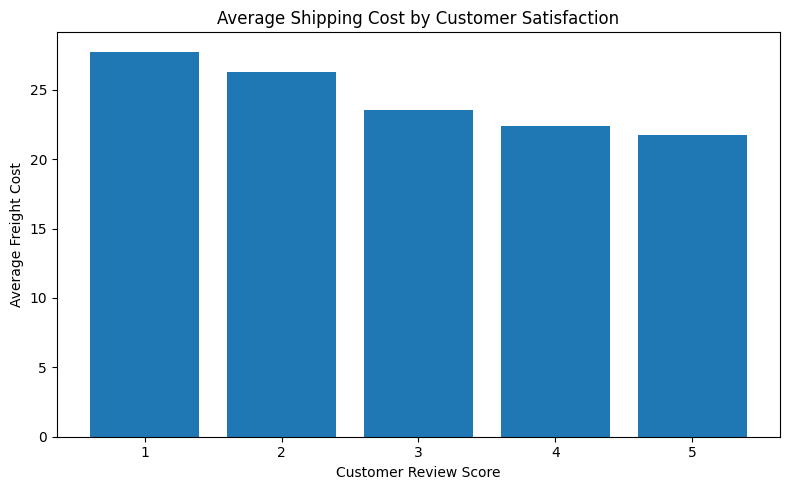

In [161]:
# ============================================================
# VISUALIZE SHIPPING COST VS CUSTOMER SATISFACTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    shipping_review_final['review_score'].astype(str),
    shipping_review_final['Avg_Freight']
)

plt.xlabel('Customer Review Score')
plt.ylabel('Average Freight Cost')
plt.title('Average Shipping Cost by Customer Satisfaction')

plt.tight_layout()
plt.show()

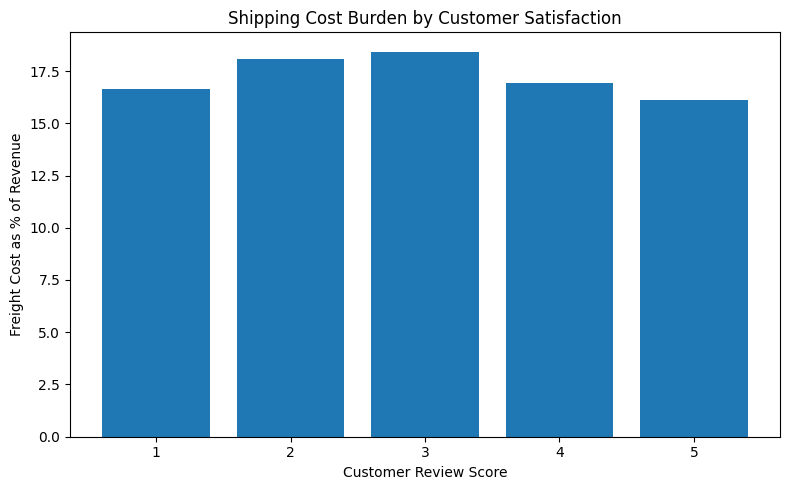

In [162]:
plt.figure(figsize=(8, 5))

plt.bar(
    shipping_review_final['review_score'].astype(str),
    shipping_review_final['Freight_pct_of_Revenue']
)

plt.xlabel('Customer Review Score')
plt.ylabel('Freight Cost as % of Revenue')
plt.title('Shipping Cost Burden by Customer Satisfaction')

plt.tight_layout()
plt.show()

In [164]:
# DELIVERY PERFORMANCE VS CUSTOMER SATISFACTION

# Create one review score per order
review_per_order = (
    order_reviews[['order_id', 'review_score']]
    .dropna()
    .groupby('order_id')['review_score']
    .mean()
    .reset_index()
)

# Select delivery information from orders
delivery_data = orders[
    [
        'order_id',
        'delivery_days',
        'Delivery_Delay_Days',
        'Delivery_Status',
        'Delivery_Delay_Category'
    ]
].copy()

# Merge delivery data with review scores
delivery_review = delivery_data.merge(
    review_per_order,
    on='order_id',
    how='inner'
)

# Analyse delivery performance by customer satisfaction
delivery_satisfaction = (
    delivery_review
    .groupby('Delivery_Status')
    .agg(
        Orders=('order_id', 'nunique'),
        Avg_Delivery_Days=('delivery_days', 'mean'),
        Avg_Delay_Days=('Delivery_Delay_Days', 'mean'),
        Avg_Review_Score=('review_score', 'mean')
    )
    .reset_index()
)

delivery_satisfaction = delivery_satisfaction.round(2)

print("DELIVERY PERFORMANCE VS CUSTOMER SATISFACTION:")
print(delivery_satisfaction)

DELIVERY PERFORMANCE VS CUSTOMER SATISFACTION:
  Delivery_Status  Orders  Avg_Delivery_Days  Avg_Delay_Days  Avg_Review_Score
0           Early   88168              10.88          -13.01              4.29
1            Late    7662              31.38            9.45              2.57
2   Not Delivered    2843                NaN             NaN              1.75


In [165]:
# DELIVERY DELAY VS REVIEW SCORE

delay_by_review = (
    delivery_review
    .groupby('review_score')
    .agg(
        Orders=('order_id', 'nunique'),
        Avg_Delivery_Days=('delivery_days', 'mean'),
        Avg_Delay_Days=('Delivery_Delay_Days', 'mean')
    )
    .reset_index()
)

delay_by_review = delay_by_review.round(2)

print("DELIVERY DELAY VS REVIEW SCORE:")
print(delay_by_review)

DELIVERY DELAY VS REVIEW SCORE:
    review_score  Orders  Avg_Delivery_Days  Avg_Delay_Days
0           1.00   11316              21.34           -3.34
1           1.50       8              17.53           -5.34
2           2.00    3125              16.66           -7.94
3           2.50      34              18.67           -6.82
4           3.00    8136              14.25          -10.08
5           3.33       1              22.03          -13.09
6           3.50      25              13.28          -13.22
7           4.00   19018              12.31          -11.68
8           4.33       1               3.77          -10.29
9           4.50      54              12.80          -12.36
10          5.00   56955              10.68          -12.68


In [168]:
# ============================================================
# PRODUCT CATEGORY PERFORMANCE — ROBUST VERSION
# ============================================================

# Safely find the existing master-level dataframe
dataframes = list(globals().items())

master_candidates = []

for name, obj in dataframes:
    if isinstance(obj, pd.DataFrame):
        cols = set(obj.columns)

        if {
            'order_id',
            'product_id',
            'Revenue',
            'Units_Sold',
            'Review_Score',
            'product_category_name'
        }.issubset(cols):
            master_candidates.append((name, obj))

print("Matching master datasets found:")

for name, df in master_candidates:
    print(f"{name}: {df.shape}")

# Select the largest matching dataframe
if len(master_candidates) == 0:
    print("\nNo suitable master dataset found.")
else:
    master_name, master_df = max(
        master_candidates,
        key=lambda x: len(x[1])
    )

    print(f"\nUsing dataset: {master_name}")
    print(f"Shape: {master_df.shape}")

    # --------------------------------------------------------
    # CATEGORY PERFORMANCE
    # --------------------------------------------------------

    category_performance = (
        master_df
        .groupby('product_category_name')
        .agg(
            Orders=('order_id', 'nunique'),
            Units_Sold=('Units_Sold', 'sum'),
            Revenue=('Revenue', 'sum'),
            Avg_Revenue_per_Order=('Revenue', 'mean'),
            Avg_Review_Score=('Review_Score', 'mean'),
            Avg_Freight_Cost=('Freight_Cost', 'mean')
        )
        .reset_index()
    )

    # Revenue contribution
    total_revenue = category_performance['Revenue'].sum()

    category_performance['Revenue_Share_%'] = (
        category_performance['Revenue'] /
        total_revenue * 100
    )

    # Sort by revenue
    category_performance = (
        category_performance
        .sort_values('Revenue', ascending=False)
        .reset_index(drop=True)
    )

    category_performance = category_performance.round(2)

    print("\nCATEGORY PERFORMANCE — TOP 15 BY REVENUE")
    print(category_performance.head(15).to_string(index=False))

Matching master datasets found:

No suitable master dataset found.


In [169]:
print("ORDER_SALES:")
print(order_sales.shape)
print(order_sales.columns.tolist())

print("\nORDER_ITEMS:")
print(order_items.shape)
print(order_items.columns.tolist())

print("\nPRODUCTS:")
print(products.shape)
print(products.columns.tolist())

ORDER_SALES:
(98666, 13)
['order_id', 'customer_id', 'customer_unique_id', 'Customer segment', 'customer_city', 'customer_state', 'order_status', 'order_purchase_timestamp', 'Revenue', 'Freight_Cost', 'Units_Sold', 'Freight_pct_of_Revenue', 'Review_Score']

ORDER_ITEMS:
(112650, 8)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'shipping_limit_time', 'price', 'freight_value']

PRODUCTS:
(32951, 10)
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'Product_Volume_cm3']


In [170]:
# ============================================================
# PRODUCT CATEGORY PERFORMANCE
# ============================================================

# 1. Connect order items with product categories
category_sales = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# 2. Add order-level information
category_sales = category_sales.merge(
    order_sales[
        ['order_id', 'Review_Score', 'order_status']
    ],
    on='order_id',
    how='left'
)

# 3. Remove products with missing category
category_sales = category_sales[
    category_sales['product_category_name'].notna()
].copy()

# ------------------------------------------------------------
# CATEGORY PERFORMANCE
# ------------------------------------------------------------

category_performance = (
    category_sales
    .groupby('product_category_name')
    .agg(
        Orders=('order_id', 'nunique'),
        Units_Sold=('order_item_id', 'count'),
        Revenue=('price', 'sum'),
        Avg_Item_Price=('price', 'mean'),
        Avg_Review_Score=('Review_Score', 'mean')
    )
    .reset_index()
)

# Revenue share
total_category_revenue = category_performance['Revenue'].sum()

category_performance['Revenue_Share_%'] = (
    category_performance['Revenue']
    / total_category_revenue
    * 100
)

# Sort by revenue
category_performance = (
    category_performance
    .sort_values('Revenue', ascending=False)
    .reset_index(drop=True)
)

category_performance = category_performance.round(2)

print("CATEGORY PERFORMANCE — TOP 15 BY REVENUE")
print(category_performance.head(15).to_string(index=False))

CATEGORY PERFORMANCE — TOP 15 BY REVENUE
 product_category_name  Orders  Units_Sold    Revenue  Avg_Item_Price  Avg_Review_Score  Revenue_Share_%
          beleza_saude    8836        9670 1258681.34          130.16              4.14             9.38
    relogios_presentes    5624        5991 1205005.68          201.14              4.02             8.98
       cama_mesa_banho    9417       11115 1036988.68           93.30              3.90             7.73
         esporte_lazer    7720        8641  988048.97          114.34              4.11             7.37
informatica_acessorios    6689        7827  911954.32          116.51              3.93             6.80
      moveis_decoracao    6449        8334  729762.49           87.56              3.91             5.44
            cool_stuff    3632        3796  635290.85          167.36              4.15             4.74
 utilidades_domesticas    5884        6964  632248.66           90.79              4.05             4.71
            au